# Fasttext tests

Based on https://github.com/BarbaraMcG/latinise/blob/83e9efdd6a216f16d89b4a181a6771c93436549f/lvlt22/Semantic_change.ipynb 

Aim:
1) For semantic shift items:
   1. compare pre- and post-christian
   2. Christian vs. non-Christian
2) For lexical replacement items:
   1. compare Christian vs. non-Christian
   2. compare replaced elements across both subcorpora? (not done yet)

Notes:
1) semantic shift items are limited to lexemes which existed prior to christianity
2) lexical replacement items are limited to lexemes borrowed via christianity (or in some cases reintroduced via christianity)

## Packages

In [2]:
import os 
import csv
import numpy as np
import pandas as pd
from gensim.models import FastText
import gensim
from scipy import spatial
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import PCA
import spacy
import plotly.express as px
import re
from statistics import mean
# to make our plot outputs appear and be stored within the notebook:
%matplotlib inline 

## Read the files

Decide if you want to work with lemmatized or unlemmatized text:

In [3]:
lemmas_or_tokens = "lemmas" # this can be "lemmas" or "tokens". because the corpus is small, using lemmas rather than tokens helps eliminate variation and achieve better results.

Find folder with corpus in directory:

In [4]:
dir_in = os.path.join("/Users", "valentinalunardi", "Documents", "UCLA_PhD", "Thesis", "Metadata_corrections")

Define path to output folder:

In [5]:
dir_out = os.path.join(dir_in, "fasttext_code", "new_semchange_output")

Define files and count them (the lemmas and tokens are grouped by text, so the number reflects the number of texts):

In [6]:
files = os.listdir(os.path.join(dir_in, "preprocessed_"+lemmas_or_tokens+"_2024"))
len(files)

1247

Use IntraText and Musisque Deoque texts in LatinISE (no LacusCurtius yet):

In [7]:
files = [f for f in files[:] if ("IT" in f or "MQDQ" in f)]
len(files)

1232

Read the metadata file:

In [8]:
metadata_df = pd.read_csv(os.path.join(dir_in, 'latinise_metadata_2024.csv'), sep = ",")
metadata_df = metadata_df[metadata_df['id'].str.startswith(("IT", "MQDQ"))]
metadata_df

,id,title,creator,date,type,file,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IT-LAT0261,Carmen Saliare,[Auctor incertus],-650,poetry,lat_0350_IT-LAT0261.txt,NaN,NaN,NaN,NaN,NaN,NaN
1,IT-LAT0285,XII Tabularum Leges,[Auctor incertus],-450,prose,lat_-0450_IT-LAT0285.txt,NaN,NaN,NaN,NaN,NaN,NaN
2,IT-LAT0262,Carmen Arvale,[Auctor incertus],-350,poetry,lat_0350_IT-LAT0262.txt,NaN,NaN,NaN,NaN,NaN,NaN
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,NaN,NaN,NaN,NaN,NaN,NaN
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1241,IT-LAT0446,Sacramentorum sanctitatis tutela,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0446.txt,NaN,NaN,NaN,NaN,NaN,NaN
1242,IT-LAT0536,Misericordia Dei,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0536.txt,NaN,NaN,NaN,NaN,NaN,NaN
1243,IT-LAT0762,Ecclesia de Eucharistia,Ioannes Paulus PP. II,2003,prose,lat_2003_IT-LAT0762.txt,NaN,NaN,NaN,NaN,NaN,NaN
1244,IT-LAT0839,Instructio Redemptionis Sacramentum,Congregatio de Cultu Divino et Disciplina Sacr...,2004,prose,lat_2004_IT-LAT0839.txt,NaN,NaN,NaN,NaN,NaN,NaN


Convert date to integer:

In [9]:
metadata_df['date'] = metadata_df['date'].astype(int)
metadata_df.dtypes

id              object
title           object
creator         object
date             int64
type            object
file            object
Unnamed: 6     float64
Unnamed: 7     float64
Unnamed: 8     float64
Unnamed: 9     float64
Unnamed: 10    float64
Unnamed: 11    float64
dtype: object

Show number of works per year:

In [10]:
metadata_df0 = metadata_df.groupby(['date']).count()
metadata_df0 = metadata_df0['id']
metadata_df0

date
-650     1
-450     1
-350     1
-290     1
-229     1
        ..
 2001    4
 2002    2
 2003    1
 2004    1
 2005    1
Name: id, Length: 379, dtype: int64

## Get rid of everything which isn't in the chosen date range (300 BCE to 600 CE)

In [11]:
metadata_df_dates_i_want = metadata_df[(metadata_df['date'] >= -300) & (metadata_df['date'] <= 600)]
metadata_ph = metadata_df_dates_i_want.copy() # A better name
metadata_ph

,id,title,creator,date,type,file,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,NaN,NaN,NaN,NaN,NaN,NaN
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,NaN,NaN,NaN,NaN,NaN,NaN
5,MQDQ-237,elogium,[Auctor incertus],-225,poetry,lat_-0255_MQDQ-237.txt,NaN,NaN,NaN,NaN,NaN,NaN
6,MQDQ-168,comoediarum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-168.txt,NaN,NaN,NaN,NaN,NaN,NaN
7,MQDQ-169,*carminum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-169.txt,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
889,MQDQ-188,epitaphium,Marius Auenticentis Episcopus,594,poetry,lat_0594_MQDQ-188.txt,NaN,NaN,NaN,NaN,NaN,NaN
890,IT-LAT0908,Sententiae,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0908.txt,NaN,NaN,NaN,NaN,NaN,NaN
891,IT-LAT0909,"Historia de regibus Gothorum, Vandalorum et Su...",Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0909.txt,NaN,NaN,NaN,NaN,NaN,NaN
892,IT-LAT0957,De natura rerum ad Sisebutum regem liber,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0957.txt,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
metadata_ph.to_csv(os.path.join(dir_out, 'metadata_restricted.csv'), index=None)

## Define time intervals (pre-Christian vs Christian)

Find the first and last date in dataset:

In [13]:
first_date = min(metadata_ph.date)
last_date = max(metadata_ph.date)
print(first_date)
print(last_date)

-290
598


Create neat intervals beginning at 300BCE and stop at 600CE

In [14]:
first_date = -300
last_date = 600

Define the size of the time intervals and find how many intervals there are:

In [15]:
size_interval = 450
n_intervals = round((last_date-first_date)/size_interval)
n_intervals

2

Define the time periods and split the corpus:

In [16]:
intervals = [None]*(n_intervals+1)
for t in range(n_intervals+1):
    #print(t)
    if t == 0:
        intervals[t] = int(first_date)
    else:
        intervals[t] = int(intervals[t-1]+size_interval)
    #print(intervals[t])
    
print(intervals)

[-300, 150, 600]


Add a column to metadata_ph for the time interval:

In [17]:
metadata_ph['time_interval'] = ""
for t in range(len(intervals)-1):
    print(t)
    print(range(intervals[t],intervals[t+1]))
    metadata_df_t = metadata_ph.loc[metadata_ph['date'].isin(range(intervals[t],intervals[t+1]))]
    print(metadata_df_t['date'])
    metadata_ph.loc[metadata_df['date'].isin(range(intervals[t],intervals[t+1])),'time_interval'] = intervals[t]
metadata_ph

0
range(-300, 150)
3     -290
4     -229
5     -225
6     -225
7     -225
      ... 
415    116
416    116
417    121
418    147
419    147
Name: date, Length: 414, dtype: int64
1
range(150, 600)
420    150
421    150
422    150
423    150
424    150
      ... 
889    594
890    598
891    598
892    598
893    598
Name: date, Length: 464, dtype: int64


,id,title,creator,date,type,file,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,time_interval
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,NaN,NaN,NaN,NaN,NaN,NaN,-300
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,NaN,NaN,NaN,NaN,NaN,NaN,-300
5,MQDQ-237,elogium,[Auctor incertus],-225,poetry,lat_-0255_MQDQ-237.txt,NaN,NaN,NaN,NaN,NaN,NaN,-300
6,MQDQ-168,comoediarum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-168.txt,NaN,NaN,NaN,NaN,NaN,NaN,-300
7,MQDQ-169,*carminum fragmenta,Liuius Andronicus,-225,poetry,lat_-0243_MQDQ-169.txt,NaN,NaN,NaN,NaN,NaN,NaN,-300
...,...,...,...,...,...,...,...,...,...,...,...,...,...
889,MQDQ-188,epitaphium,Marius Auenticentis Episcopus,594,poetry,lat_0594_MQDQ-188.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
890,IT-LAT0908,Sententiae,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0908.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
891,IT-LAT0909,"Historia de regibus Gothorum, Vandalorum et Su...",Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0909.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
892,IT-LAT0957,De natura rerum ad Sisebutum regem liber,Isidorus Hispalensis Episcopus,598,prose,lat_0598_IT-LAT0957.txt,NaN,NaN,NaN,NaN,NaN,NaN,150


Visualise distribution of time intervals:

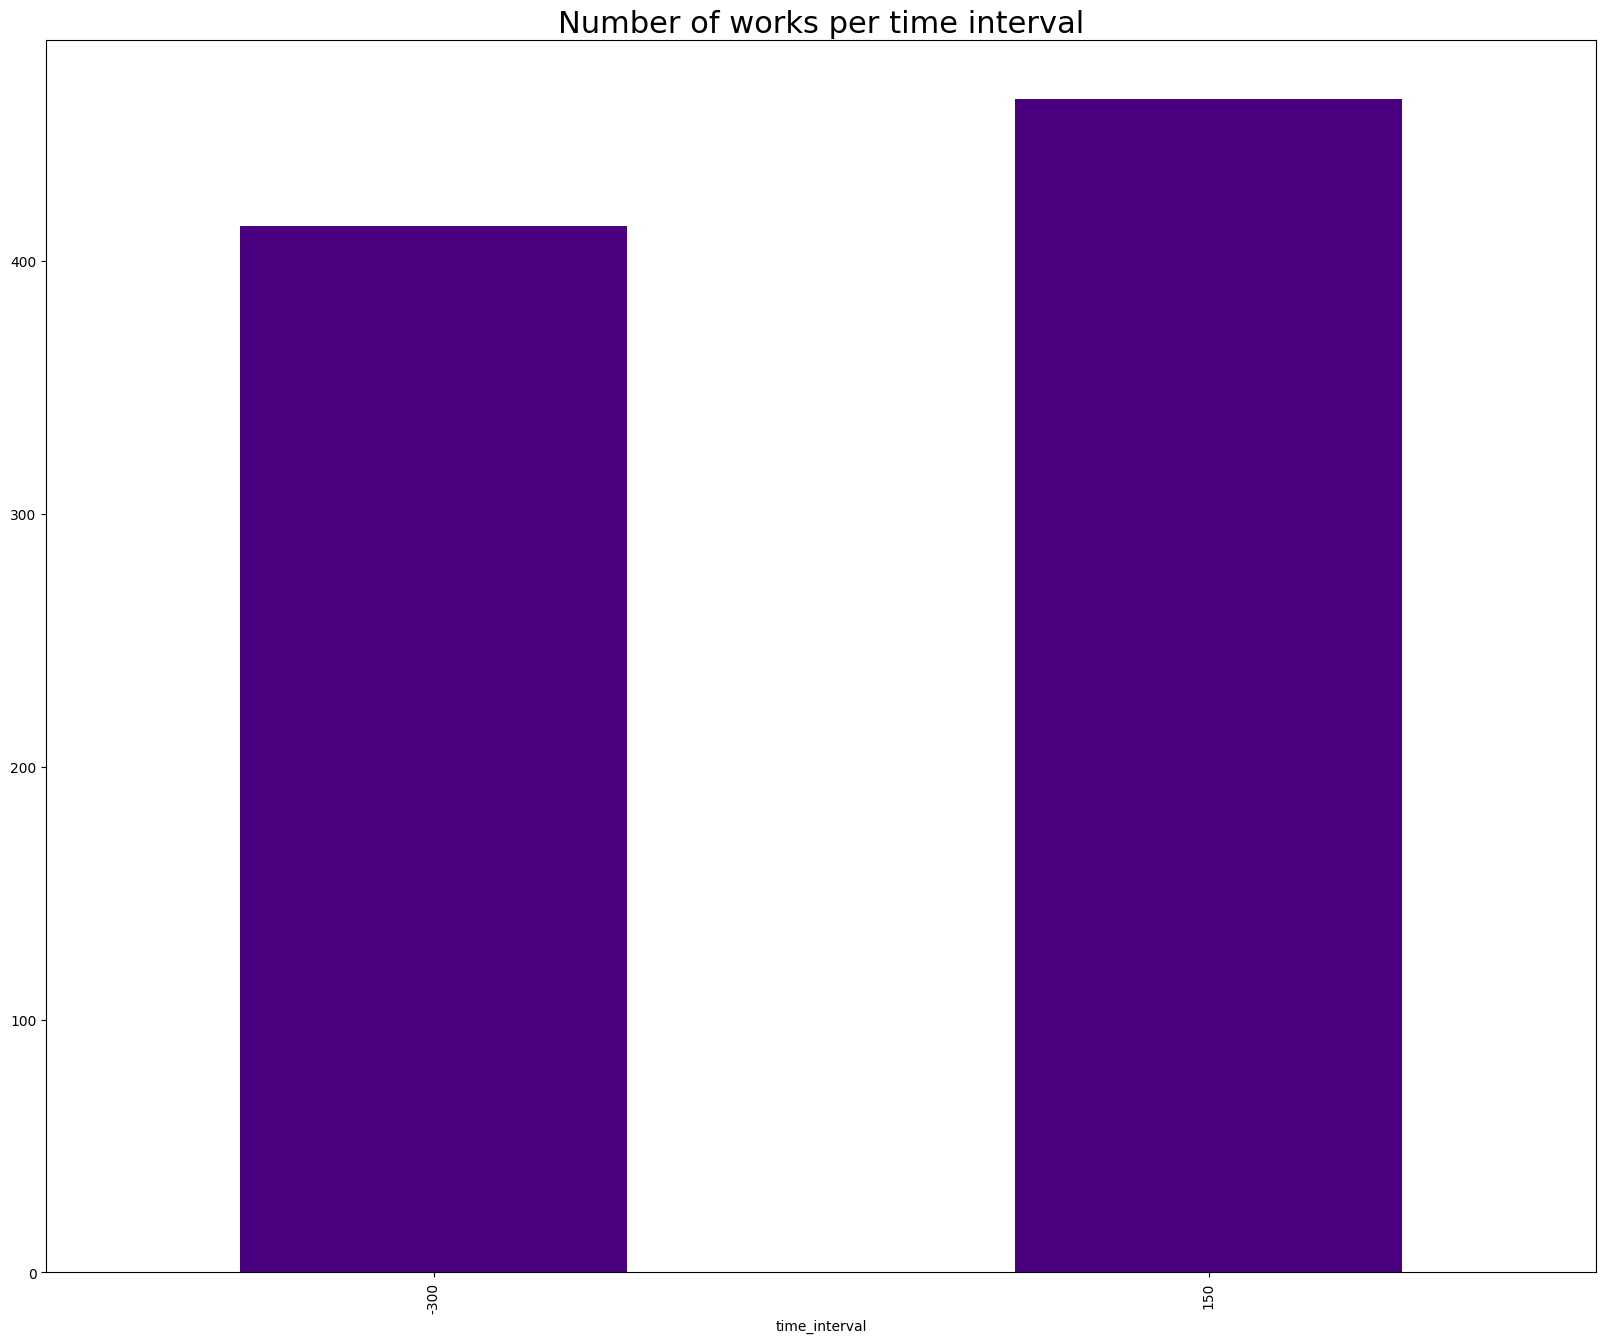

In [18]:
metadata_df0 = metadata_ph.groupby(['time_interval']).count()
metadata_df0 = metadata_df0['id']
metadata_df0
ax = metadata_df0.plot(kind='bar', figsize=(20,16), color="indigo", fontsize=10);
ax.set_title("Number of works per time interval", fontsize=22)
plt.show()

### Notes on chronological subcorpora
1) There are more texts in the second interval, but this does not result in imbalance. The number of tokens is actually slighlty higher for the first time interval (see count further down).
2) About two thirds of the texts in the second time interval are Christian. This might be a problem. Do a token count, and if there are issues, we might need to either cut down on the Christian texts or add more non-Christian texts. On second thought: keep in mind that 70 of the Christian texts make up the Vulgate, so we might be alright in the end in terms of balance.
3) The 300 BCE start date is deceiving – IT texts do not include a whole lot of early stuff (e.g. no trace of Ennius, Livius Andronicus, Naevus, Plautus (only 1 comedy), Terence). Some of this could be fixed by introducing some early MQDQ texts, making sure there are no clashes.
4) The choice to split at 150 CE depends solely on the dating of Minucius Felix in the corpus, which in my opinion seems early. I originally thought I would have the Christian interval start at 200 CE, but maybe it doesn't make much of a difference in the end.

## Split into subcorpora by genre (Christian vs non-Christian)

### Christian subcorpus

Notes on which authors in IT corpus for Christian subcorpus (but should check if some texts need to be excluded within authors): 
- 3rd century and earlier: Tertullian, Novatian, Minucius Felix, Arnobius, Lactantius, Commodian, Egeria, (not in IT, but maybe worth seeking out: Cyprian, Victorinus of Pettau, Itinerarium Burdigalense, Hyppolitus, Dyonisus + more texts from authors that are there) 
- 4-6th century: St Jerome, St Ambrose, St Augustine, Prudentius, Sedulius, Boethius, Sulpicius Severus, Prosper Aquitanus, Paulinus of Nola~, Hydatius, Benedict of Nursia, Thomas of Edessa, Macarius of Alexandria, Eucherius of Lyon, Vincent de Lérins, Marcellinus Comes (weird formatting though), Apophthegmata (but only Macarius Magnus and Praefatio in IT), Cassiodorus (check which texts), Martin of Braga (check which texts), Gregory of Tours (??), Isidore of Seville (check which texts), (I am sure there are more potential texts outside of IT, but this is probably enough for now)

Notes on which authors in MQDQ corpus (but should check better about texts within authors):
- Unsure: Boethius
- Sure: Tertullian, Commodian, Lactantius, Laudes domini, Iuvencus, Proba, Marius Victorinus, Hilarius Pictaviensis, St Ambrose, Damasus, Prudentius, St Augustine, Paulinus of Nola, Pseudo Cyprian, Paulinus Pellaeus, Agrestius Gallus, Auspicius Tullensis, Carmen Sibyllinum, Cyprianus Gallus, Dracontius (partial), Paulinus Baeterrensis, Orientius, Paulinus Petricordiae, Prosper Aquitanus, Sedulius, Victorinus, Marius Victor, Sidonius Apollinaris, Ruricius Lemovicensis, Anonymous, Parthenius Africanus, Alcimus Avitus, Cyprianus Tolonensis, Remigius Remensis, Ennodius, Arator, Flavius Cabilonensis, Marcus Casinensis, Rusticius Helpidius, Severus Malacitanus, Columba, Columbanus, Martin of Braga, Marius of Avenches, Isidor of Seville

Select Christian texts and count them:

In [19]:
commodian = ['MQDQ-39', 'MQDQ-40', 'MQDQ-41']
tertullian = ['MQDQ-491', 'MQDQ-492']
lactantius = ['MQDQ-157', 'MQDQ-158', 'MQDQ-159']
laudes_dom = ['MQDQ-1']
iuvencus = ['MQDQ-151']
proba = ['MQDQ-350']
marius_vic = ['MQDQ-617']
hilarius_pic = ['MQDQ-117', 'MQDQ-118', 'MQDQ-119', 'MQDQ-120']
ambrose = ['MQDQ-179', 'MQDQ-180', 'MQDQ-181', 'MQDQ-182', 'MQDQ-183']
damasus = ['MQDQ-56']
prudentius = ['MQDQ-366', 'MQDQ-367', 'MQDQ-368', 'MQDQ-369', 'MQDQ-371', 'MQDQ-372', 'MQDQ-373', 'MQDQ-374', 'MQDQ-375']
augustine = ['MQDQ-512', 'MQDQ-513', 'MQDQ-514', 'MQDQ-515', 'MQDQ-516']
paulinus_nol = ['MQDQ-279', 'MQDQ-280', 'MQDQ-281', 'MQDQ-282']
pseud_cyp = ['MQDQ-379', 'MQDQ-380', 'MQDQ-381', 'MQDQ-382', 'MQDQ-383']
paulinus_pel = ['MQDQ-283', 'MQDQ-284']
agrestius_gal = ['MQDQ-66']
auspicius_tul = ['MQDQ-608']
carmen_sib = ['MQDQ-5']
cyprian_gal = ['MQDQ-48', 'MQDQ-49', 'MQDQ-50', 'MQDQ-51', 'MQDQ-52', 'MQDQ-53', 'MQDQ-54', 'MQDQ-55']
dracontius = ['MQDQ-59', 'MQDQ-60']
paulinus_bae = ['MQDQ-278']
orientius = ['MQDQ-242', 'MQDQ-243']
paulinus_pet = ['MQDQ-285', 'MQDQ-286', 'MQDQ-287']
prosper_aqu = ['MQDQ-360', 'MQDQ-361', 'MQDQ-362', 'MQDQ-363', 'MQDQ-364', 'MQDQ-365']
sedulius = ['MQDQ-422', 'MQDQ-423']
victorinus = ['MQDQ-564', 'MQDQ-565', 'MQDQ-566']
marius_vic = ['MQDQ-189']
sidonius = ['MQDQ-444', 'MQDQ-445']
ruricius_lem = ['MQDQ-111']
anonymous = ['MQDQ-140']
parthenius_afr = ['MQDQ-277']
alcimus_avi = ['MQDQ-622', 'MQDQ-623']
cyprianus_tol = ['MQDQ-621']
remigius_rem = ['MQDQ-618']
gildas = ['MQDQ-574', 'MQDQ-575']
# boethius = ['MQDQ-627', 'MQDQ-628']
ennodius = ['MQDQ-75', 'MQDQ-76', 'MQDQ-77', 'MQDQ-78', 'MQDQ-79', 'MQDQ-80', 'MQDQ-81', 'MQDQ-82', 'MQDQ-83', 'MQDQ-84', 'MQDQ-85', 'MQDQ-86']
arator = ['MQDQ-351', 'MQDQ-352', 'MQDQ-353', 'MQDQ-354', 'MQDQ-355']
flavius_cab = ['MQDQ-95']
marcus_cas = ['MQDQ-244']
rusticius_hel = ['MQDQ-415', 'MQDQ-416']
severus_mal = ['MQDQ-191']
columba = ['MQDQ-619']
columbanus = ['MQDQ-30', 'MQDQ-31', 'MQDQ-32', 'MQDQ-33', 'MQDQ-34', 'MQDQ-35']
martin_bra = ['MQDQ-209', 'MQDQ-210', 'MQDQ-211']
marius_ave = ['MQDQ-188']
isidore_sev = ['MQDQ-148']
selected_texts_2 = commodian + tertullian + lactantius + laudes_dom + iuvencus + proba + marius_vic + hilarius_pic + ambrose + damasus + prudentius + augustine + paulinus_nol + pseud_cyp + paulinus_pel + agrestius_gal + auspicius_tul + carmen_sib + cyprian_gal + dracontius + paulinus_bae + orientius + paulinus_pet + prosper_aqu + sedulius + victorinus + sidonius + ruricius_lem + anonymous + parthenius_afr + alcimus_avi + cyprianus_tol + remigius_rem + gildas + ennodius + arator + flavius_cab + marcus_cas + rusticius_hel + severus_mal + columba + columbanus + martin_bra + marius_ave + isidore_sev

In [20]:
tertullian = ['LAT0058', 'LAT0062','LAT0246', 'LAT0248', 'LAT0256', 'LAT0350', 'LAT0448', 'LAT0606', 'LAT0733', 'LAT0736', 'LAT0737', 'LAT0744', 'LAT0746', 'LAT0747', 'LAT0749', 'LAT0750', 'LAT0755', 'LAT0788']
novatian = ['LAT0865']
minucius_felix = ['LAT0267']
arnobius = ['LAT0264']
lactantius = ['LAT0268']
commodian = ['LAT0607']
egeria = ['LAT0719']
auctor_incertus_1 = ['LAT0471', 'LAT0203']
early_selected_texts = tertullian + novatian + minucius_felix + arnobius + lactantius + commodian + egeria + auctor_incertus_1
jerome1 = ['LAT0001', 'LAT0001_1', 'LAT0001_2', 'LAT0001_3', 'LAT0001_4', 'LAT0001_5', 'LAT0001_6', 'LAT0001_7', 'LAT0001_8', 'LAT0001_9', 'LAT0001_10', 'LAT0001_11', 'LAT0001_12', 'LAT0001_13', 'LAT0001_14', 'LAT0001_15', 'LAT0001_16', 'LAT0001_17', 'LAT0001_18', 'LAT0001_19', 'LAT0001_20', 'LAT0001_21', 'LAT0001_22', 'LAT0001_23', 'LAT0001_24', 'LAT0001_25', 'LAT0001_26', 'LAT0001_27', 'LAT0001_28', 'LAT0001_29', 'LAT0001_30', 'LAT0001_31', 'LAT0001_32', 'LAT0001_33', 'LAT0001_34', 'LAT0001_35']
jerome2 = ['LAT0001_36', 'LAT0001_37', 'LAT0001_38', 'LAT0001_39', 'LAT0001_40', 'LAT0001_41', 'LAT0001_42', 'LAT0001_43', 'LAT0001_44', 'LAT0001_45', 'LAT0001_46', 'LAT0001_47', 'LAT0001_48', 'LAT0001_49', 'LAT0001_50', 'LAT0001_51', 'LAT0001_52', 'LAT0001_53', 'LAT0001_54', 'LAT0001_55', 'LAT0001_56', 'LAT0001_57', 'LAT0001_58', 'LAT0001_59', 'LAT0001_60', 'LAT0001_61', 'LAT0001_62', 'LAT0001_63', 'LAT0001_64', 'LAT0001_65', 'LAT0001_66', 'LAT0001_67', 'LAT0001_68', 'LAT0001_69', 'LAT1039', 'LAT0726', 'LAT0843', 'LAT0878', 'LAT0880']
augustine = ['LAT0061', 'LAT0793', 'LAT0016', 'LAT0015', 'LAT0397', 'LAT0403', 'LAT0768']
ambrose = ['LAT0263', 'LAT0847']
paulinus_nola = ['LAT0609']
sulpicius_severus = ['LAT0612', 'LAT0410']
apophthegmata = ['LAT0978']
hydatius = ['LAT0775', 'LAT0776']
macarius_alex = ['LAT1004']
prudentius = ['LAT0270']
prosper_aquit = ['LAT0610']
sedulius = ['LAT0414']
eucherius_lyon = ['LAT0608']
vincent_lerins = ['LAT0904']
# boethius = ['LAT0917']
benedict_nursia = ['LAT0011']
cassiodorus = ['LAT0250', 'LAT0251', 'LAT0252', 'LAT0243', 'LAT0482']
thomas_edessa = ['LAT0875']
marcellinus_comes = ['LAT0791']
gregory_tours = ['LAT0783']
martin_braga = ['LAT0990', 'LAT0990_1', 'LAT0990_2', 'LAT0990_3', 'LAT0990_4', 'LAT0990_5', 'LAT0990_6', 'LAT0990_7', 'LAT0990_8', 'LAT0990_9']
isidore_seville = ['LAT0908', 'LAT0909', 'LAT0957']
auctor_incertus_2 = ['LAT0383']
late_selected_texts = jerome1 + jerome2 + augustine + ambrose + paulinus_nola + sulpicius_severus + apophthegmata + hydatius + macarius_alex + prudentius + prosper_aquit + sedulius + eucherius_lyon + vincent_lerins + benedict_nursia + cassiodorus + thomas_edessa + marcellinus_comes + gregory_tours + martin_braga + isidore_seville + auctor_incertus_2 # + boethius
selected_texts_1 = early_selected_texts + late_selected_texts
selected_texts_1 = ['IT-'+f for f in selected_texts_1]
selected_texts_1

['IT-LAT0058',
 'IT-LAT0062',
 'IT-LAT0246',
 'IT-LAT0248',
 'IT-LAT0256',
 'IT-LAT0350',
 'IT-LAT0448',
 'IT-LAT0606',
 'IT-LAT0733',
 'IT-LAT0736',
 'IT-LAT0737',
 'IT-LAT0744',
 'IT-LAT0746',
 'IT-LAT0747',
 'IT-LAT0749',
 'IT-LAT0750',
 'IT-LAT0755',
 'IT-LAT0788',
 'IT-LAT0865',
 'IT-LAT0267',
 'IT-LAT0264',
 'IT-LAT0268',
 'IT-LAT0607',
 'IT-LAT0719',
 'IT-LAT0471',
 'IT-LAT0203',
 'IT-LAT0001',
 'IT-LAT0001_1',
 'IT-LAT0001_2',
 'IT-LAT0001_3',
 'IT-LAT0001_4',
 'IT-LAT0001_5',
 'IT-LAT0001_6',
 'IT-LAT0001_7',
 'IT-LAT0001_8',
 'IT-LAT0001_9',
 'IT-LAT0001_10',
 'IT-LAT0001_11',
 'IT-LAT0001_12',
 'IT-LAT0001_13',
 'IT-LAT0001_14',
 'IT-LAT0001_15',
 'IT-LAT0001_16',
 'IT-LAT0001_17',
 'IT-LAT0001_18',
 'IT-LAT0001_19',
 'IT-LAT0001_20',
 'IT-LAT0001_21',
 'IT-LAT0001_22',
 'IT-LAT0001_23',
 'IT-LAT0001_24',
 'IT-LAT0001_25',
 'IT-LAT0001_26',
 'IT-LAT0001_27',
 'IT-LAT0001_28',
 'IT-LAT0001_29',
 'IT-LAT0001_30',
 'IT-LAT0001_31',
 'IT-LAT0001_32',
 'IT-LAT0001_33',
 'IT-LAT00

In [21]:
selected_texts = selected_texts_1 + selected_texts_2

In [22]:
len(selected_texts)

267

Display selection metadata:

In [23]:
metadata_ph_christian = metadata_ph[(metadata_ph['id'].isin(selected_texts))]
metadata_ph_christian
metadata_ph_christian.to_csv(os.path.join(dir_out, 'metadata_christian.csv'), index=None)

In [24]:
metadata_ph_christian['time_interval'].min()

150

### Non-Christian control subcorpus (post 150 CE)

Select post 150 CE non-Christian texts by exclusion and display metadata:

In [25]:
metadata_ph_nonchristian = metadata_ph[(metadata_ph['time_interval']==150) & (~metadata_ph['id'].isin(selected_texts))]
metadata_ph_nonchristian

,id,title,creator,date,type,file,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,time_interval
421,IT-LAT0360,Noctes Atticae,"Gellius, Aulus",150,prose,lat_0150_IT-LAT0360.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
422,IT-LAT0406,De nugis philosophorum,"Balbus, [Pseudo-] Caecilius",150,prose,lat_0150_IT-LAT0406.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
423,IT-LAT0407,Quaestiones,"Caecilius Africanus, Sextus",150,prose,lat_0150_IT-LAT0407.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
424,IT-LAT0916,De verbis dubiis,"Caper, Flavius",150,prose,lat_0150_IT-LAT0916.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
425,MQDQ-223,carminum fragmenta,Annianus,150,poetry,lat_0150.0_MQDQ-223.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
...,...,...,...,...,...,...,...,...,...,...,...,...,...
869,MQDQ-347,carmen in laudem Anastasii imperatoris,Priscianus,550,poetry,lat_0550.0_MQDQ-347.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
870,MQDQ-348,carminis fragmentum,Priscianus,550,poetry,lat_0550.0_MQDQ-348.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
871,MQDQ-346,perihegesis,Priscianus,550,poetry,lat_0550.0_MQDQ-346.txt,NaN,NaN,NaN,NaN,NaN,NaN,150
875,MQDQ-475,sylloge cod. Elnonensis,sylloge cod. Elnonensis,550,poetry,lat_0550.0_MQDQ-475.txt,NaN,NaN,NaN,NaN,NaN,NaN,150


In [26]:
nonchristian_selected_texts = list(metadata_ph_nonchristian['id'])
nonchristian_selected_texts

['IT-LAT0360',
 'IT-LAT0406',
 'IT-LAT0407',
 'IT-LAT0916',
 'MQDQ-223',
 'MQDQ-490',
 'MQDQ-240',
 'MQDQ-293',
 'MQDQ-345',
 'MQDQ-470',
 'MQDQ-465',
 'MQDQ-471',
 'MQDQ-467',
 'MQDQ-466',
 'MQDQ-469',
 'MQDQ-472',
 'MQDQ-468',
 'IT-LAT0043',
 'MQDQ-540',
 'IT-LAT0201',
 'IT-LAT0204',
 'IT-LAT0621',
 'IT-LAT0665',
 'IT-LAT0846',
 'IT-LAT0913',
 'IT-LAT0914',
 'MQDQ-123',
 'MQDQ-138',
 'MQDQ-234',
 'MQDQ-233',
 'MQDQ-232',
 'MQDQ-343',
 'MQDQ-344',
 'MQDQ-558',
 'IT-LAT0893',
 'IT-LAT0895',
 'IT-LAT0896',
 'IT-LAT0351',
 'MQDQ-107',
 'MQDQ-447',
 'MQDQ-87',
 'MQDQ-241',
 'MQDQ-290',
 'MQDQ-377',
 'MQDQ-378',
 'MQDQ-393',
 'MQDQ-499',
 'MQDQ-500',
 'MQDQ-563',
 'IT-LAT0886',
 'MQDQ-166',
 'MQDQ-149',
 'IT-LAT0115',
 'IT-LAT0233',
 'IT-LAT0238',
 'IT-LAT0286',
 'IT-LAT0353',
 'IT-LAT0361',
 'IT-LAT0362',
 'IT-LAT0364',
 'IT-LAT0365',
 'IT-LAT0366',
 'IT-LAT0367',
 'IT-LAT0850',
 'IT-LAT0919',
 'MQDQ-569',
 'MQDQ-570',
 'MQDQ-571',
 'MQDQ-573',
 'MQDQ-10',
 'MQDQ-609',
 'MQDQ-192',
 'MQDQ

I have not trained embeddings on the subcorpora yet, but perhaps it would make more sense to move this whole section at the end, just before training the two subcorpora in the second time interval?

## Train embeddings for whole 300 BCE to 600 CE corpus

Function for printing the vocabulary of a model:

In [27]:
def print_vocab(model, top_n = None):
  if model == '':
    print("Empty model!")
  else:
    count = 0
    if top_n is not None:
      for index, word in enumerate(model.wv.index_to_key):
        count+= 1
        if count < top_n:
          print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")
    else:
      for index, word in enumerate(model.wv.index_to_key):
        print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")

Function that converts dates into the standard format:

In [28]:
def convert_dates(sign, date0):

    if sign == "0":
        if date0 == 0:
            final_date = "+0000"
        elif date0 < 100:
            final_date = "+" + "00" + str(date0)
            #print("1-final_date", final_date)
        elif date0 < 1000:
            final_date = "+" + "0" + str(date0)
            #print("2-final_date", final_date)
        else:
            final_date = "+" + str(date0)
            #print("3-final_date", final_date)
    else:
        if date0 == 0:
            final_date = "+0000"
        elif date0 < 100:
            final_date = str(sign) + "00" + str(date0)
            #print("1-final_date", final_date)
        elif date0 < 1000:
            final_date = str(sign) + "0" + str(date0)
            #print("2-final_date", final_date)
        else:
            final_date = str(sign) + str(date0)
            #print("3-final_date", final_date)

    if final_date.startswith("+"):
        final_date = final_date.replace("+", "")
    return final_date

### Stopwords exclusion and further filtering

Exclude punctuation marks:

In [29]:
punctuation = ['.', ',', '...', ';', ':', '?']

### Make corpus

Create a list of lists, containing the (lemmatized) tokens of each sentence in the whole corpus (excluding punctuation):

In [30]:
corpus = list()
files_corpus = metadata_ph
for index, df_line in files_corpus.iterrows():
    #print("line:",df_line['id'], df_line['time_interval'])
    sign = "+"
    #print(df_line['date'])
    if df_line['date'] < 0:
        sign = "-"
    #print("date:", convert_dates(sign, abs(df_line['date'])))
    file_name = df_line['file']#'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
    print("3:",file_name)
    file = open(os.path.join(dir_in, "preprocessed_"+lemmas_or_tokens+"_2024", file_name), 'r')
    #sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            #sentences_this_file.append(line.split(" "))
            #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
            corpus.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
#corpus.append(sentences_this_file)

3: lat_-0300_MQDQ-288.txt
3: lat_-0229_IT-LAT1006.txt
3: lat_-0255_MQDQ-237.txt
3: lat_-0243_MQDQ-168.txt
3: lat_-0243_MQDQ-169.txt
3: lat_-0243_MQDQ-167.txt
3: lat_-0234_MQDQ-228.txt
3: lat_-0234_MQDQ-230.txt
3: lat_-0234_MQDQ-229.txt
3: lat_-0234_MQDQ-227.txt
3: lat_-0234_MQDQ-226.txt
3: lat_-0203_MQDQ-74.txt
3: lat_-0203_MQDQ-73.txt
3: lat_-0203_MQDQ-70.txt
3: lat_-0203_MQDQ-72.txt
3: lat_-0203_MQDQ-71.txt
3: lat_-0218_MQDQ-323.txt
3: lat_-0149.0_MQDQ-164.txt
3: lat_-0218_MQDQ-306.txt
3: lat_-0218_MQDQ-307.txt
3: lat_-0218_MQDQ-308.txt
3: lat_-0218_MQDQ-309.txt
3: lat_-0218_MQDQ-310.txt
3: lat_-0218_MQDQ-311.txt
3: lat_-0218_MQDQ-312.txt
3: lat_-0218_MQDQ-313.txt
3: lat_-0218_MQDQ-314.txt
3: lat_-0218_MQDQ-327.txt
3: lat_-0218_MQDQ-315.txt
3: lat_-0218_MQDQ-316.txt
3: lat_-0218_MQDQ-317.txt
3: lat_-0218_MQDQ-318.txt
3: lat_-0218_MQDQ-319.txt
3: lat_-0218_MQDQ-322.txt
3: lat_-0218_MQDQ-324.txt
3: lat_-0218_MQDQ-325.txt
3: lat_-0218_MQDQ-326.txt
3: lat_0000_IT-LAT0181.txt
3: lat_-0218

Show the corpus:

In [31]:
corpus

[['amicus',
  'cum',
  'video',
  'obliuiscere',
  'miseria',
  'inimicus',
  'si',
  'sum',
  'commentus',
  'nec',
  'libet',
  'aequus'],
 ['postremus', 'dico#2', 'primus', 'taceo'],
 ['apud',
  'Latinus',
  'Marcius',
  'vates',
  'primus',
  'praeceptum',
  'compono',
  'ex',
  'quis#2',
  'sum',
  'ille',
  'postr'],
 ['-', 'tac'],
 [],
 ['ne', 'ningulus', 'mederi', 'queo', 'Ningulus', 'nullus'],
 ['Marcius', 'vates', 'ne', '-', 'queo'],
 ['hic',
  'unus',
  'plurimus',
  'consentio',
  'gens',
  'populus',
  'primarius',
  'sum',
  'vir'],
 ['Pulicesne', 'an', 'cimices', 'an', 'pes'],
 ['respondeo', 'ego'],
 ['corruo', 'quasi', 'iacio', 'secena'],
 ['Sicine'],
 ['Hau', 'multus', 'secus'],
 [],
 [],
 ['ornamentum',
  'incedo',
  'gnobiles',
  'ignobilis',
  'affatim',
  'Edi',
  'bibo',
  'ludo',
  'uecorde',
  'et',
  'maleficum',
  'Vacerra',
  'Lepus',
  'tueor',
  'sum',
  'pulpamentum',
  'quaero'],
 ['meus', 'puera', 'quis#2', 'uerbi', 'ex', 'tuus', 'os#1', 'supra', 'fugio'

Count how many sentences in corpus:

In [32]:
len(corpus)

422972

### Train with FastText and play with parameters

Function for training FastText models (from Krzysztof Nowak):

In [32]:
def fasttext(self, opts=dict()):
        """
        Reads sentences from the corpus. Implements:
            https://radimrehurek.com/gensim/models/fasttext.html#gensim.models.fasttext.FastText
        Returns
        -------
        FastText model
        """
        default_opts = dict(vector_size=100, alpha=0.025,
                            window=5, min_count=5, epochs=5)
        opts_new = default_opts
        for opt in opts.keys():
            opts_new[opt] = opts[opt]
        model = FastText(
            vector_size=opts_new["vector_size"],
            alpha=opts_new["alpha"],
            window=opts_new["window"],
            min_count=opts_new["min_count"])
        model.build_vocab(corpus_iterable=[sentence for sentence in
                                           self.corpus.get_sents()])
        total_examples = model.corpus_count
        model.train(corpus_iterable=[sentence for sentence
                                     in self.corpus.get_sents()],
                    total_examples=total_examples,
                    epochs=opts_new["epochs"])
        return model

Parameters:

`min_count`: the minimum frequency threshold allowed for a word to be included; set to 3 following Ribary & McGillivray (2020) or 5 following Sprugnoli et al. (2019).

`vector_size`: the number of dimensions in which we wish to represent our word. This is the size of the word embedding; typically between 100 and 1,000. Set to 100 following Ribary & McGillivray (2020).

`window`: The size of the context window determines how many words before and after a given word would be included as context words of the given word. Typically between 5 and 10. Set to 10 following Sprugnoli et al. (2020).

`sg`: – Training algorithm: 1 for skip-gram; otherwise CBOW. Set to 10 following Ribary & McGillivray (2020).

QUESTIONS:
1) It looks like `sg` was used in the code with word2vec, but not with fasttext – is it not relevant for fasttext? does it have a default I'm unaware of?
2) What is the role of `alpha`?

Train FastText embeddings and, for full reproducibility, limit the model to a single worker thread (workers=1), to eliminate ordering jitter from OS thread scheduling:

QUESTION:
What is the role of `workers`? I don't think I understand the sentence above.

In [33]:
model = FastText(vector_size=100, alpha=0.025, window=1, min_count=50, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)

(25669617, 34163080)

Let's see what words are similar to "deus":

In [34]:
model.wv.similar_by_word('deus', 10)

[('dominus', 0.6498351693153381),
 ('lapideus', 0.6088551878929138),
 ('dea', 0.608496904373169),
 ('christus', 0.5938597321510315),
 ('divinus', 0.5823104381561279),
 ('Christus', 0.5812532901763916),
 ('quominus', 0.5796331763267517),
 ('dominatus', 0.5741158127784729),
 ('deuota', 0.566639244556427),
 ('dominator', 0.552588939666748)]

Let's try with different parameters:

In [35]:
start = time.time()
model = FastText(vector_size=100, window=5, min_count=5, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 124 seconds


[('Tydeus', 0.8494255542755127),
 ('deu', 0.829310953617096),
 ('deuexa', 0.7631828188896179),
 ('Diomedeus', 0.7177985310554504),
 ('semideus', 0.7121793031692505),
 ('deuoti', 0.6763986945152283),
 ('Christus', 0.6665254831314087),
 ('deuexo', 0.6639180779457092),
 ('spondeus', 0.6568623781204224),
 ('lapideus', 0.6510533690452576)]

In [36]:
start = time.time()
model = FastText(vector_size=100, window=10, min_count=5, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 191 seconds


[('Tydeus', 0.8613553643226624),
 ('deu', 0.8358835577964783),
 ('deuexa', 0.7643582820892334),
 ('semideus', 0.7424825429916382),
 ('Diomedeus', 0.7224067449569702),
 ('deuexo', 0.696245014667511),
 ('Christus', 0.6805629730224609),
 ('spondeus', 0.68006432056427),
 ('lapideus', 0.675530195236206),
 ('deuouet', 0.6542074084281921)]

The model has a vocabulary of

In [37]:
model.corpus_total_words

6832616

words and

In [38]:
model.corpus_count

422972

sentences.

Different configurations of the parameters for the embeddings against the gold standard set by Sprugnoli et al. (2019) (https://github.com/CIRCSE/Lemma-Embeddings-for-Latin/blob/master/syn-selection-benchmark-Latin.tsv) are evaluated to find the best configuration of parameters here: https://gitlab.surrey.ac.uk/mr0048/pydigest/-/blob/master/script/fasttext_003.py

## Train embeddings for each time interval

### Make corpora for time intervals

For each time interval, read the texts from files and create a list of lists, i.e. a list of sentences (excluding punctuation):

In [47]:
# dictionary that maps a time interval with the list of sentences of texts in that time interval"
time2corpus = dict()

# I loop over all time intervals:
for t in range(n_intervals+1):
    files_corpus_t = metadata_ph.loc[metadata_ph['time_interval'] == intervals[t]]
    #print("1:",files_corpus_t, type(files_corpus_t))
    corpus_t = list()
    for index, df_line in files_corpus_t.iterrows():
        #print("line:",df_line['id'], df_line['time_interval'])
        sign = "+"
        #print(df_line['date'])
        if df_line['date'] < 0:
            sign = "-"
        #print("date:", convert_dates(sign, abs(df_line['date'])))
        file_name = df_line['file']#'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
        #print("3:",file_name)
        file = open(os.path.join(dir_in, "preprocessed_"+lemmas_or_tokens+"_2024", file_name), 'r')
        sentences_this_file = list()
        while True:
            line = file.readline().strip()
            if line != "":
                #sentences_this_file.append(line.split(" "))
                #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
                corpus_t.append([token for token in line.split(" ") if token not in punctuation])
            # if line is empty end of file is reached
            if not line:
                break
        file.close()
        #corpus_t.append(sentences_this_file)
    #corpus_t1
    #print(len(corpus_t1[0]))
    time2corpus[t] = corpus_t

### Check if the two corpora have a similar amount of tokens

Show the subcorpus for the first time interval:

In [40]:
time2corpus[0]

[['amicus',
  'cum',
  'video',
  'obliuiscere',
  'miseria',
  'inimicus',
  'si',
  'sum',
  'commentus',
  'nec',
  'libet',
  'aequus'],
 ['postremus', 'dico#2', 'primus', 'taceo'],
 ['apud',
  'Latinus',
  'Marcius',
  'vates',
  'primus',
  'praeceptum',
  'compono',
  'ex',
  'quis#2',
  'sum',
  'ille',
  'postr'],
 ['-', 'tac'],
 [],
 ['ne', 'ningulus', 'mederi', 'queo', 'Ningulus', 'nullus'],
 ['Marcius', 'vates', 'ne', '-', 'queo'],
 ['hic',
  'unus',
  'plurimus',
  'consentio',
  'gens',
  'populus',
  'primarius',
  'sum',
  'vir'],
 ['Pulicesne', 'an', 'cimices', 'an', 'pes'],
 ['respondeo', 'ego'],
 ['corruo', 'quasi', 'iacio', 'secena'],
 ['Sicine'],
 ['Hau', 'multus', 'secus'],
 [],
 [],
 ['ornamentum',
  'incedo',
  'gnobiles',
  'ignobilis',
  'affatim',
  'Edi',
  'bibo',
  'ludo',
  'uecorde',
  'et',
  'maleficum',
  'Vacerra',
  'Lepus',
  'tueor',
  'sum',
  'pulpamentum',
  'quaero'],
 ['meus', 'puera', 'quis#2', 'uerbi', 'ex', 'tuus', 'os#1', 'supra', 'fugio'

Count sentences for first time interval:

In [41]:
len(time2corpus[0])

204795

In [42]:
# Number of words
num_words_int_0 = sum(len(i) for i in time2corpus[0])
num_words_int_0

3701638

Show the subcorpus for the second time interval:

In [43]:
time2corpus[1]

[['cogito',
  'ego',
  'et',
  'cum',
  'animus',
  'meus',
  'Octavius',
  'bonus',
  'et',
  'fidelis',
  'contubernalis',
  'memoria',
  'recenseo',
  'tantus',
  'dulcedo',
  'et',
  'adfectio',
  'homo',
  'inhaeresco',
  'ut',
  'ipse',
  'quodammodo',
  'ego',
  'video',
  'in',
  'praeteritus',
  'redeo',
  'non',
  'is',
  'quis#2',
  'iam',
  'transigo',
  'et',
  'decurro',
  'sum',
  'recordatio',
  'revoco',
  'ita',
  'is',
  'contemplatio',
  'quantum',
  'subtraho',
  'sum',
  'oculus',
  'tantus',
  'pectus',
  'meus',
  'atque',
  'paene',
  'intimus',
  'sensus',
  'inplicata',
  'sum'],
 ['nec',
  'inmeritum',
  'discedo',
  'vir',
  'eximius',
  'et',
  'sanctus',
  'inmensum',
  'suus',
  'desiderium',
  'nos',
  'relinquo',
  'utpote',
  'cum',
  'et',
  'ipse',
  'tanto',
  'noster',
  'semper',
  'amor',
  'flagraverit',
  'ut',
  'et',
  'in',
  'ludicrum',
  'et',
  'seria',
  'par',
  'ego',
  'voluntas',
  'concino',
  'idem',
  'volo#1',
  'vel',
  'nolo',

Count sentences for second time interval:

In [44]:
len(time2corpus[1])

218177

In [45]:
# Number of words
num_words_int_1 = sum(len(i) for i in time2corpus[1])
num_words_int_1

3130978

In [46]:
# Ratio of word counts
num_words_int_0/num_words_int_1

1.1822625390532926

The two time intervals are therefore fairly balanced in terms of number of tokens, despite the big difference in number of texts.

### Train with FastText and play with parameters

Following the findings of Sprugnoli et al. (2019) and Ribary & McGillivray (2020), train a fasttext model for each time interval:

Train embeddings for the first time interval:

In [47]:
start = time.time()
#model = gensim.models.Word2Vec(time2corpus[0], min_count=5, vector_size=100, window = 10, sg = 1)
start = time.time()
model = FastText(vector_size=100, window=5, min_count=5, workers=1, seed=1,hashfxn=hash)
model.build_vocab(corpus_iterable=time2corpus[0])
model.train(corpus_iterable=time2corpus[0], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 66 seconds


[('Tydeus', 0.8824177384376526),
 ('Diomedeus', 0.8451873660087585),
 ('deu', 0.836553692817688),
 ('semideus', 0.8002678751945496),
 ('deuexa', 0.7857157588005066),
 ('lapideus', 0.7647174596786499),
 ('deuexo', 0.7569472789764404),
 ('dea', 0.744405210018158),
 ('deuouet', 0.7122834920883179),
 ('Iuppiter', 0.6948562860488892)]

In [48]:
print_vocab(model, 10)

word #0/25724 is sum
word #1/25724 is et
word #2/25724 is quis#2
word #3/25724 is in
word #4/25724 is is
word #5/25724 is hic
word #6/25724 is non
word #7/25724 is ut
word #8/25724 is cum


The corpus is small and the fasttext seems to prefer orthographic similarity with smaller min_counts. We're not interested in deus being similar to lapideus, but rather in deus being similar to divunus or immortalis. So, we have two options: we may either turn off the subwords or apply high frequency threshold (but we're going to lose low-frequency terms).

Try changing the parameters to exclude subwords (set `max_n` to 0):

In [49]:
start = time.time()
#model = gensim.models.Word2Vec(time2corpus[0], min_count=5, vector_size=100, window = 10, sg = 1)
start = time.time()
model = FastText(vector_size=100, window=10, min_count=5, workers=1, seed=1, hashfxn=hash, max_n=0) 
model.build_vocab(corpus_iterable=time2corpus[0])
model.train(corpus_iterable=time2corpus[0], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 16 seconds


[('numen', 0.7335605025291443),
 ('Iuppiter', 0.7164009213447571),
 ('dea', 0.6747964024543762),
 ('superi', 0.6421559453010559),
 ('diuum', 0.6253941059112549),
 ('caelestis', 0.6141847372055054),
 ('omen', 0.6085290312767029),
 ('nefas', 0.5849953293800354),
 ('precatus', 0.5766925811767578),
 ('fas', 0.5686618685722351)]

In [50]:
model.wv.similar_by_word('dominus', 10)

[('dominium', 0.7534686326980591),
 ('pauper', 0.7150866985321045),
 ('domina', 0.6647341251373291),
 ('hereditas', 0.6140488386154175),
 ('emptor', 0.6080697178840637),
 ('dos', 0.6042361855506897),
 ('dives', 0.599706768989563),
 ('hospitium', 0.5849093794822693),
 ('mancipium', 0.5847085118293762),
 ('amica', 0.5840921401977539)]

Additionally, we could set a higher frequency threshold (set `min_count` to 50 rather than 5), but we would lose low-frequency terms:

In [51]:
start = time.time()
#model = gensim.models.Word2Vec(time2corpus[0], min_count=5, vector_size=100, window = 10, sg = 1)
start = time.time()
model = FastText(vector_size=100, window=10, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0) 
model.build_vocab(corpus_iterable=time2corpus[0])
model.train(corpus_iterable=time2corpus[0], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 13 seconds


[('numen', 0.6980730295181274),
 ('Iuppiter', 0.6730678081512451),
 ('dea', 0.6372430920600891),
 ('caelestis', 0.6340125203132629),
 ('superi', 0.5852124691009521),
 ('precatus', 0.5446888208389282),
 ('divinus', 0.5332857966423035),
 ('sanctus', 0.5308413505554199),
 ('adoro', 0.5297765135765076),
 ('diuum', 0.5279618501663208)]

In [52]:
model.wv.similar_by_word('dominus', 10)

[('dominium', 0.7378504276275635),
 ('pauper', 0.6785911917686462),
 ('emptor', 0.6509307026863098),
 ('venalis', 0.6281570792198181),
 ('domina', 0.6160549521446228),
 ('servus', 0.6017882227897644),
 ('serva', 0.5981389880180359),
 ('dives', 0.5916030406951904),
 ('praedium', 0.583496630191803),
 ('mancipium', 0.5780702233314514)]

Train embeddings for all time intervals (however many):

In [66]:
models = list()
start = time.time()
for t in range(len(time2corpus)):
    if len(time2corpus[t])>0:
        print(t)
        #model = gensim.models.Word2Vec(time2corpus[0][0], min_count=1, vector_size=300, window = 5, sg = 0)
        model = FastText(vector_size=100, window=5, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0)  # instantiate
        model.build_vocab(corpus_iterable=time2corpus[t])
        model.train(corpus_iterable=time2corpus[t], total_examples=len(time2corpus[t]), epochs=10)  # train
        models.append(model)
        #model = fasttext.train_unsupervised(time2corpus[0][0], model='skipgram')
end = time.time()
print("It has taken", round(end - start), "seconds, or ", round((end - start)/60), "minutes")

0
1
It has taken 52 seconds, or  1 minutes


Check some models:

In [54]:
print_vocab(models[0], 20)

word #0/5689 is sum
word #1/5689 is et
word #2/5689 is quis#2
word #3/5689 is in
word #4/5689 is is
word #5/5689 is hic
word #6/5689 is non
word #7/5689 is ut
word #8/5689 is cum
word #9/5689 is ad
word #10/5689 is ego
word #11/5689 is ille
word #12/5689 is ab
word #13/5689 is quod
word #14/5689 is atque
word #15/5689 is si
word #16/5689 is omnis
word #17/5689 is sed
word #18/5689 is se


In [97]:
models[0].wv.similar_by_word('deus', 10)

[('immortalis', 0.6355789303779602),
 ('dea', 0.5682703852653503),
 ('numen', 0.5665861368179321),
 ('superi', 0.5485014915466309),
 ('inmortales', 0.502573549747467),
 ('diuis', 0.4850917458534241),
 ('Iuppiter', 0.4798741638660431),
 ('propitius', 0.4782281517982483),
 ('invoco', 0.4768076241016388),
 ('diuum', 0.46931368112564087)]

In [56]:
print_vocab(models[1], 20)

word #0/5252 is et
word #1/5252 is sum
word #2/5252 is in
word #3/5252 is quis#2
word #4/5252 is is
word #5/5252 is non
word #6/5252 is hic
word #7/5252 is ab
word #8/5252 is ad
word #9/5252 is ut
word #10/5252 is cum
word #11/5252 is si
word #12/5252 is suus
word #13/5252 is de
word #14/5252 is quod
word #15/5252 is ille
word #16/5252 is omnis
word #17/5252 is dico#2
word #18/5252 is sed


In [57]:
models[0].wv.get_vecattr('deus', "count")

5408

In [58]:
models[1].wv.get_vecattr('deus', "count")

15086

In [120]:
models[1].wv.get_vecattr('panis', "count")

227

In [121]:
models[0].wv.get_vecattr('panis', "count")

260

In [52]:
models[0].wv.get_vecattr('oratio', "count")

2295

In [53]:
models[1].wv.get_vecattr('oratio', "count")

950

In [54]:
models[1].wv.similar_by_word('deus', 10)

[('dominus', 0.5754846334457397),
 ('omnipotens', 0.551090657711029),
 ('creator', 0.5255251526832581),
 ('Christus', 0.5139051079750061),
 ('factor', 0.5110411047935486),
 ('iustitia', 0.4731229543685913),
 ('sanctificatio', 0.47011107206344604),
 ('glorifico', 0.4635041654109955),
 ('diuina', 0.45219147205352783),
 ('trinitas', 0.44183164834976196)]

In [67]:
models[0].wv.similar_by_word('communico', 10)

[('praesertim', 0.5986396670341492),
 ('delibero', 0.5787398815155029),
 ('comprobo', 0.5446533560752869),
 ('probo', 0.5301541090011597),
 ('consulo', 0.5292500257492065),
 ('accusator', 0.527418315410614),
 ('excuso', 0.5213179588317871),
 ('advocatus', 0.5142530202865601),
 ('patronus', 0.5129578709602356),
 ('suadeo', 0.5060204267501831)]

In [68]:
models[1].wv.similar_by_word('communico', 10)

[('praesumo', 0.6343563795089722),
 ('reservo', 0.605745792388916),
 ('consentio', 0.5833152532577515),
 ('abstineo', 0.5708245635032654),
 ('denego', 0.5666906833648682),
 ('exhibeo', 0.5603576898574829),
 ('relaxo', 0.5513924360275269),
 ('excuso', 0.5501413941383362),
 ('suggero', 0.5477381944656372),
 ('renuntio', 0.5475344061851501)]

In [69]:
models[0].wv.similar_by_word('communio', 10)

[('munio', 0.7510166764259338),
 ('munito', 0.6788476705551147),
 ('expugno', 0.6442002058029175),
 ('saepio', 0.6351531744003296),
 ('circumdo', 0.5949317216873169),
 ('occupo', 0.5911279916763306),
 ('perfugio', 0.5863896012306213),
 ('firmo', 0.5817943811416626),
 ('munitio', 0.5742445588111877),
 ('trans', 0.5737627148628235)]

In [71]:
models[1].wv.similar_by_word('communio', 10)

[('consortio', 0.5981824398040771),
 ('intentio', 0.5772457122802734),
 ('emendatio', 0.5748648643493652),
 ('monasterium', 0.5616386532783508),
 ('firmitas', 0.5589063167572021),
 ('sacramentum', 0.5510188937187195),
 ('professio', 0.5428399443626404),
 ('audientia', 0.5252323150634766),
 ('lite', 0.5142955780029297),
 ('proprietas', 0.5083715319633484)]

In [111]:
models[0].wv.similar_by_word('oratio', 10)

[('disputatio', 0.7186176776885986),
 ('sermo', 0.6734350919723511),
 ('actio', 0.6706967949867249),
 ('sententia', 0.6420950889587402),
 ('lectio', 0.6367026567459106),
 ('verbum', 0.6237901449203491),
 ('expositio', 0.6092801094055176),
 ('narratio', 0.6077786087989807),
 ('auditor', 0.5939515233039856),
 ('interrogatio', 0.5928928256034851)]

In [112]:
models[1].wv.similar_by_word('oratio', 10)

[('lectio', 0.5930050611495972),
 ('vigilia', 0.4493023455142975),
 ('scriptum', 0.4374464154243469),
 ('epistula', 0.43507903814315796),
 ('intentio', 0.4321258068084717),
 ('interrogatio', 0.4301456809043884),
 ('confessio', 0.4289151728153229),
 ('verbum', 0.42327165603637695),
 ('vaco', 0.41434231400489807),
 ('oro', 0.4091646373271942)]

In [104]:
models[0].wv.similar_by_word('memoria', 10)

[('posteritas', 0.531648576259613),
 ('monumentum', 0.5111051797866821),
 ('oblivio', 0.4300948679447174),
 ('nota', 0.4275611937046051),
 ('annalis', 0.41803857684135437),
 ('antiquitas', 0.4160798192024231),
 ('recordatio', 0.412811279296875),
 ('notitia', 0.398406982421875),
 ('litterae', 0.3771129548549652),
 ('relatio', 0.3723357617855072)]

In [122]:
models[1].wv.similar_by_word('panis', 10)

[('panus', 0.7426244020462036),
 ('bibo', 0.685680091381073),
 ('saturo', 0.6622979044914246),
 ('vinum', 0.6599963903427124),
 ('oleum', 0.637322187423706),
 ('cibus', 0.6252411007881165),
 ('calix', 0.6029376983642578),
 ('lac', 0.5866861343383789),
 ('esca', 0.5742583274841309),
 ('victima', 0.5686217546463013)]

In [123]:
models[0].wv.similar_by_word('panis', 10)

[('panus', 0.686540424823761),
 ('lana', 0.6763428449630737),
 ('corium', 0.6618900299072266),
 ('acetum', 0.6556174159049988),
 ('lac', 0.6420072913169861),
 ('mella', 0.6390882134437561),
 ('sucus', 0.624977171421051),
 ('calix', 0.6244804859161377),
 ('pomum', 0.6222469210624695),
 ('linteum', 0.6183061599731445)]

In [67]:
models[1].wv.similar_by_word('propheta', 10)

[('Esaias', 0.7270694971084595),
 ('prophetia', 0.6644656658172607),
 ('praedico#2', 0.6478306651115417),
 ('Hieremias', 0.6478227972984314),
 ('Moses', 0.6054272055625916),
 ('Zaccharias', 0.575141429901123),
 ('apostolus', 0.565260648727417),
 ('Samuhel', 0.5599877238273621),
 ('patriarcha', 0.5531390905380249),
 ('Hieu', 0.5453464388847351)]

In [68]:
models[0].wv.similar_by_word('desertum', 10)

[('desertus', 0.5863491296768188),
 ('hospita', 0.5690991878509521),
 ('relinquo', 0.5505198240280151),
 ('incola', 0.5418254733085632),
 ('exsul', 0.5304295420646667),
 ('uenerat', 0.5272667407989502),
 ('depopulor', 0.5212199687957764),
 ('profugus', 0.5171994566917419),
 ('Tusculum', 0.5155543088912964),
 ('diripio', 0.5142507553100586)]

In [69]:
models[1].wv.similar_by_word('desertum', 10)

[('solitudo', 0.724946141242981),
 ('mons', 0.5614675283432007),
 ('Samaria', 0.5605418086051941),
 ('desertus', 0.5594815611839294),
 ('ascendo', 0.5586046576499939),
 ('vallis', 0.557321310043335),
 ('puteus', 0.5476658344268799),
 ('Hiericho', 0.5461588501930237),
 ('Iordanes', 0.5459225177764893),
 ('Hierosolyma', 0.542441725730896)]

In [70]:
#models[1].wv.similar_by_word('eremus', 10)

In [71]:
models[1].wv.similar_by_word('virtus', 10)

[('fortitudo', 0.6171936988830566),
 ('prudentia', 0.5846312046051025),
 ('gloria', 0.5794703960418701),
 ('potentia', 0.5605321526527405),
 ('admiratio', 0.5599128007888794),
 ('pulchritudo', 0.5506372451782227),
 ('uirtutis', 0.5463308691978455),
 ('laudabilis', 0.5410645008087158),
 ('claritas', 0.5406966805458069),
 ('sanctitas', 0.5389838814735413)]

In [72]:
models[0].wv.similar_by_word('virtus', 10)

[('prudentia', 0.6602511405944824),
 ('laus', 0.6596344113349915),
 ('industrius', 0.6491618156433105),
 ('eloquentia', 0.6431368589401245),
 ('gloria', 0.6362489461898804),
 ('temperantia', 0.6328303813934326),
 ('sapientia', 0.6302920579910278),
 ('honestas', 0.6271699666976929),
 ('fortitudo', 0.618990957736969),
 ('moderatio', 0.6184266209602356)]

In [73]:
models[0].wv.similar_by_word('gratia', 10)

[('dignitas', 0.6000487804412842),
 ('beneficium', 0.5924689769744873),
 ('benevolentia', 0.5867419838905334),
 ('meritum', 0.5729289054870605),
 ('Gratia', 0.5565832853317261),
 ('invidia', 0.5524608492851257),
 ('amicitia', 0.5352038741111755),
 ('grates', 0.5324878096580505),
 ('miseratio', 0.5289270877838135),
 ('facilitas', 0.5203136801719666)]

In [74]:
models[1].wv.similar_by_word('gratia', 10)

[('benignitas', 0.5432733297348022),
 ('donum', 0.5376819968223572),
 ('honor', 0.5305799841880798),
 ('consolatio', 0.5244923233985901),
 ('munus', 0.5223832130432129),
 ('misericordia', 0.4951098561286926),
 ('glorifico', 0.49291321635246277),
 ('caritas', 0.49207383394241333),
 ('indulgentia', 0.48590993881225586),
 ('beneficium', 0.48541155457496643)]

In [113]:
models[0].wv.similar_by_word('lex', 10)

[('ius', 0.5928292870521545),
 ('jus', 0.5857967138290405),
 ('suffragium', 0.5827069878578186),
 ('auspicium', 0.563696563243866),
 ('magistratus', 0.557792067527771),
 ('decretum', 0.55609530210495),
 ('conditio', 0.5408740639686584),
 ('maiestas', 0.529364287853241),
 ('libertas', 0.5274587273597717),
 ('iudicium', 0.5115718245506287)]

In [114]:
models[1].wv.similar_by_word('lex', 10)

[('constitutio', 0.6680530309677124),
 ('observatio', 0.6076815128326416),
 ('praeceptum', 0.5695621967315674),
 ('tenor', 0.5366559028625488),
 ('edictum', 0.532189130783081),
 ('jus', 0.5268171429634094),
 ('auctoritas', 0.5062088966369629),
 ('generalis', 0.5060526728630066),
 ('regula', 0.5052290558815002),
 ('caerimonia', 0.49435973167419434)]

### Embedding space alignment

Code from https://gist.github.com/zhicongchen/9e23d5c3f1e5b1293b16133485cd17d8, ported from HistWords https://github.com/williamleif/histwords.

Function to find the intersection between the vocabularies of two word2vec models:

In [74]:
def intersection_align_gensim(m1, m2, words=None):
    """
    Intersect two gensim word2vec models, m1 and m2.
    Only the shared vocabulary between them is kept.
    If 'words' is set (as list or set), then the vocabulary is intersected with this list as well.
    Indices are re-organized from 0..N in order of descending frequency (=sum of counts from both m1 and m2).
    These indices correspond to the new syn0 and syn0norm objects in both gensim models:
        -- so that Row 0 of m1.syn0 will be for the same word as Row 0 of m2.syn0
        -- you can find the index of any word on the .index2word list: model.index2word.index(word) => 2
    The .vocab dictionary is also updated for each model, preserving the count but updating the index.
    """

    # Get the vocab for each model
    vocab_m1 = set(m1.wv.index_to_key)
    vocab_m2 = set(m2.wv.index_to_key)

    # Find the common vocabulary
    common_vocab = vocab_m1 & vocab_m2
    if words: common_vocab &= set(words)

    # If no alignment necessary because vocab is identical...
    if not vocab_m1 - common_vocab and not vocab_m2 - common_vocab:
        return (common_vocab, m1,m2)

    # Otherwise sort by frequency (summed for both)
    common_vocab = list(common_vocab)
    common_vocab.sort(key=lambda w: m1.wv.get_vecattr(w, "count") + m2.wv.get_vecattr(w, "count"), reverse=True)
    # print(len(common_vocab))

    # Then for each model...
    for m in [m1, m2]:
        # Replace old syn0norm array with new one (with common vocab)
        indices = [m.wv.key_to_index[w] for w in common_vocab]
        old_arr = m.wv.vectors
        new_arr = np.array([old_arr[index] for index in indices])
        m.wv.vectors = new_arr

        # Replace old vocab dictionary with new one (with common vocab)
        # and old index2word with new one
        new_key_to_index = {}
        new_index_to_key = []
        for new_index, key in enumerate(common_vocab):
            new_key_to_index[key] = new_index
            new_index_to_key.append(key)
        m.wv.key_to_index = new_key_to_index
        m.wv.index_to_key = new_index_to_key
        
        print(len(m.wv.key_to_index), len(m.wv.vectors))
        
    print(common_vocab)
    print(m1)
    print(m2)
    return (common_vocab, m1, m2)

Function for aligning two spaces with Orthogonal Procrustes:

In [75]:
def smart_procrustes_align_gensim(base_embed, other_embed, words=None):
    """
    Original script: https://gist.github.com/quadrismegistus/09a93e219a6ffc4f216fb85235535faf
    Procrustes align two gensim word2vec models (to allow for comparison between same word across models).
    Code ported from HistWords <https://github.com/williamleif/histwords> by William Hamilton <wleif@stanford.edu>.
        
    First, intersect the vocabularies (see `intersection_align_gensim` documentation).
    Then do the alignment on the other_embed model.
    Replace the other_embed model's syn0 and syn0norm numpy matrices with the aligned version.
    Return other_embed.
    If `words` is set, intersect the two models' vocabulary with the vocabulary in words (see `intersection_align_gensim` documentation).
    """

    # make sure vocabulary and indices are aligned
    common_vocab, in_base_embed, in_other_embed = intersection_align_gensim(base_embed, other_embed, words=words)

    # re-filling the normed vectors: the following two lines were added following Japleen Gulati, following amacanovic's comments in the discussion below this page: https://gist.github.com/zhicongchen/9e23d5c3f1e5b1293b16133485cd17d8

    in_base_embed.wv.fill_norms(force=True)
    in_other_embed.wv.fill_norms(force=True)
    
    # get the (normalized) embedding matrices
    base_vecs = in_base_embed.wv.get_normed_vectors()
    other_vecs = in_other_embed.wv.get_normed_vectors()
    
    # just a matrix dot product with numpy
    m = other_vecs.T.dot(base_vecs) 
    # SVD method from numpy
    u, _, v = np.linalg.svd(m)
    # another matrix operation
    ortho = u.dot(v) 
    # Replace original array with modified one, i.e. multiplying the embedding matrix by "ortho"
    other_embed.wv.vectors = (other_embed.wv.vectors).dot(ortho)    
    
    return other_embed

Apply the function to the two models:

In [76]:
smart_procrustes_align_gensim(models[1], models[0])

4057 4057
4057 4057
['et', 'sum', 'in', 'quis#2', 'is', 'non', 'hic', 'ut', 'cum', 'ad', 'ab', 'ille', 'si', 'quod', 'ego', 'omnis', 'sed', 'atque', 'dico#2', 'suus', 'se', 'ex', 'de', 'tu', 'ipse', 'facio', 'possum', 'quam#4', 'nec', 'per', 'aut', 'res', 'deus', 'habeo', 'do', 'qui', 'video', 'alius', 'multus', 'enim', 'tuus', 'autem', 'vel', 'iam', 'etiam', 'meus', 'magnus', 'ne#2', 'homo', '"', 'quo', 'unus', 'idem', "'", 'noster', 'nos', 'dies', 'tamen', 'rex', 'primus', 'pater', 'dominus', 'locus', 'modus', 'tempus', 'filius', 'bonus', 'pars', 'neque', 'ita', 'verus', 'quoque', 'venio', 'nunc', 'causa', 'pro', 'nullus', 'quia', 'sic', 'terra', 'vos', 'nomen', 'tantus', 'nihil', 'quidem', 'imperator', 'ago', 'inter', 'bellum', 'animus', 'corpus', 'quidam', 'manus', 'post', 'fero', 'Romanus', 'vir', 'fio', 'namque', 'urbs', 'iste', 'aliquis', 'ante', 'solus', 'tum', 'ubi', 'verbum', '!', 'annus', 'volo#1', 'sine', 'lex', 'nisi', '-', 'domus', 'parvus', 'mitto', 'tuuus', 'credo', 'ge

Now the models have been aligned and have the same vocabulary:

In [77]:
for i in range(0,len(models)):
    print(i, len(models[i].wv.index_to_key))

0 4057
1 4057


QUESTION: I am not sure I have a full understanding of what's happening here. I think the idea is to make sure that we are only looking at the vocab which is common to all time intervals for which embeddings were trained – is this right?

### Semantic change with cosine similarity

In [78]:
intervals

[-300, 150, 600]

In [111]:
len(intervals)

3

In [112]:
models

Define a function that, given a reference step (either "first" or "last"), it returns the time intervals' range to be used to compare models against this reference step:

In [79]:
def find_reference_intervals(reference_step, intervals):
    
    if reference_step == "first":
        #range_intervals = range(intervals[1], intervals[len(intervals)-1], size_interval)
        #range_intervals_index = range(1, len(intervals)-1)
        #reference_interval = intervals[0]
        reference_interval_index = 0
    elif reference_step == "last":
        #range_intervals = range(intervals[0], intervals[len(intervals)-2], size_interval)
        #range_intervals_index = range(0, len(intervals)-2)
        #reference_interval = intervals[len(intervals)-1]
        reference_interval_index = len(intervals)-2
        
    #return (range_intervals, range_intervals_index, reference_interval, reference_interval_index)
    return reference_interval_index

In [80]:
find_reference_intervals("first", intervals)

0

In [81]:
find_reference_intervals("last", intervals)

1

Let's define a function that calculates the cosine similarity between the embedding of a word in a time interval t and the embedding of the same word in the reference time interval:

In [82]:
def cosine_similarity(word, t, reference_step, models, intervals):
    #(range_intervals, range_intervals_index, reference_interval, reference_interval_index)= find_reference_intervals(reference_step)
    reference_interval_index = find_reference_intervals(reference_step, intervals)
    sc = np.nan
    if models[reference_interval_index] == '':
        print("Model of reference interval is empty!")
    else:
        if models[t] != '':
            #print(t, word)
            sc = 1-spatial.distance.cosine(models[t].wv[word], models[reference_interval_index].wv[word])
    return sc

In [85]:
cosine_similarity("deus", 1, "first", models, intervals)

0.6180554032325745

In [119]:
cosine_similarity("communico", 1, "first", models, intervals)

0.42002102732658386

Now define a function that, given a reference step and a time interval index (starting from 0 for the first model), calculates the semantic similarity for all words in the vocabulary between these two time intervals, and stores this in the dataframe cosine_similarity_ph:

In [86]:
def cosine_similarity_dataframe(reference_step, time_interval_index, models, intervals):
    if time_interval_index<0 or time_interval_index>len(models)-1:
        print("Second argument needs to be between 0 and ", len(models)-1)
        
    reference_interval_index = find_reference_intervals(reference_step, intervals)
    #print(reference_interval_index)
    if models[reference_interval_index] != '' and models[time_interval_index] != '':
        cosine_similarity_ph = pd.DataFrame(([w, 
            models[reference_interval_index].wv.get_vecattr(w, "count"),
            models[time_interval_index].wv.get_vecattr(w, "count"),
            cosine_similarity(w,time_interval_index, reference_step, models, intervals)  
            ] for w in models[time_interval_index].wv.index_to_key), 
        columns = ('Word', 
                   "Frequency_t_reference-"+str(reference_step), 
                   "Frequency_t"+str(time_interval_index), 
                   'Cosine_similarity(w_t_reference-'+str(reference_step)+',w_t'+str(time_interval_index)+')'))
    else:
        print("The reference model or the current model are empty!")
        cosine_similarity_ph = pd.DataFrame()
    return cosine_similarity_ph

In [87]:
cosine_similarity_dataframe("last", 0, models, intervals)

,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)"
0,et,128676,117636,0.535618
1,sum,84730,94747,0.800644
2,in,64137,73628,0.697661
3,quis#2,56687,67421,0.849785
4,is,47487,44812,0.749064
...,...,...,...,...
4052,consolatio,75,83,0.252016
4053,VII,75,83,0.604274
4054,sibilus,75,83,0.709023
4055,deceptus,75,83,0.620667


Visualise the distribution of the semantic similarity scores with a histogram:

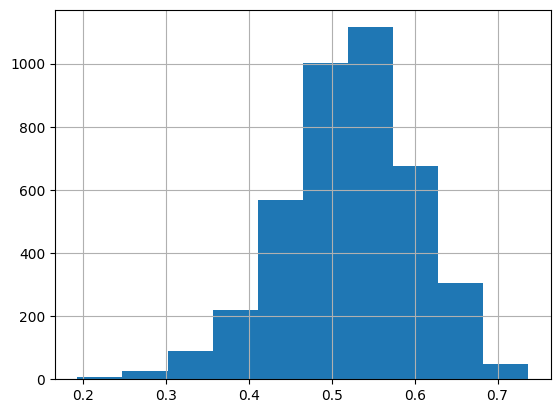

In [121]:
hist = cosine_similarity_dataframe("last", 0, models, intervals).iloc[:,-1].hist()

Now possible to store the full time series of the cosine similarity between the embedding of a word in each time interval and the embedding of that same word in the reference interval (set to "last"):

In [122]:
intervals

[-300, 150, 600]

In [88]:
reference_step = "last"
time_series = list()
reference_interval_index = find_reference_intervals(reference_step, intervals)
time_series_ph = pd.DataFrame()
#for w in models[reference_interval_index].wv.index_to_key:
df = cosine_similarity_dataframe(reference_step, reference_interval_index, models, intervals)
time_series_ph[df.columns[0]] = df.iloc[:,0]
time_series_ph[df.columns[1]] = df.iloc[:,1]
for i in range(len(models)):
    #print(reference_interval_index)
    print("Interval", str(intervals[i]), "with", str(list(intervals)[reference_interval_index]))
    df = cosine_similarity_dataframe(reference_step, i, models, intervals)
#    if i == reference_interval_index:
#        time_series_ph = df
#        col_i = "interval-"+str(reference_interval_index)
#        time_series_ph[col_i] = [reference_interval_index for w in models[reference_interval_index].wv.index_to_key]
#        col_n = "neighbours_ref-"+reference_step
#        time_series_ph[col_n] = [models[reference_interval_index].wv.similar_by_word(w, 10) for w in models[reference_interval_index].wv.index_to_key]
#    else:
#        #time_series_ph = time_series_ph, df.iloc[:,-2:]
#        tmp_ph = df.iloc[:,-2:]
#        #df.iloc[:,-2:].column[0]
#        #print(tmp_ph.iloc[:,0])
#        time_series_ph[tmp_ph.columns[0]] = tmp_ph.iloc[:,0]
#        time_series_ph[tmp_ph.columns[1]] = tmp_ph.iloc[:,1]
#        col_i = "interval-"+str(i)
#        time_series_ph[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
#        #Finding top 10 nearest neighbours:
#        col_n = "neighbours_t"+str(i)
#        time_series_ph[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
    if i != reference_interval_index:
        tmp_ph = df.iloc[:,-2:]
        #df.iloc[:,-2:].column[0]
        #print(df.iloc[:,0])
        time_series_ph[tmp_ph.columns[0]] = tmp_ph.iloc[:,0]
        time_series_ph[tmp_ph.columns[1]] = tmp_ph.iloc[:,1]
        col_i = "interval-"+str(i)
        time_series_ph[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
        #Finding top 10 nearest neighbours:
        col_n = "neighbours_t"+str(i)
        time_series_ph[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
        #print(time_series_ph)
    else:
        tmp_ph = df.iloc[:,-2:]
        #df.iloc[:,-2:].column[0]
        #print(df.iloc[:,0])
        time_series_ph[tmp_ph.columns[0]] = tmp_ph.iloc[:,0]
        time_series_ph[tmp_ph.columns[1]] = tmp_ph.iloc[:,1]
        col_i = "interval-"+str(i)
        time_series_ph[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
        #Finding top 10 nearest neighbours:
        col_n = "neighbours_t"+str(i)
        time_series_ph[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
    
time_series_ph

Interval -300 with 150
Interval 150 with 150


,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)",interval-0,neighbours_t0,Frequency_t1,"Cosine_similarity(w_t_reference-last,w_t1)",interval-1,neighbours_t1
0,et,128676,117636,0.535618,0,"[(atque, 0.6844799518585205), (eademque, 0.514...",128676,1,1,"[(autem, 0.5450320243835449), (sicut, 0.463234..."
1,sum,84730,94747,0.800644,0,"[(habeo, 0.5811508893966675), (fio, 0.49497801...",84730,1,1,"[(habeo, 0.5789471864700317), (appareo, 0.5252..."
2,in,64137,73628,0.697661,0,"[(circa, 0.5559099912643433), (ex, 0.513976812...",64137,1,1,"[(extra, 0.5212802290916443), (de, 0.497641295..."
3,quis#2,56687,67421,0.849785,0,"[(quod, 0.7040718793869019), (quos, 0.53789681...",56687,1,1,"[(quod, 0.6494575142860413), (qui, 0.642443776..."
4,is,47487,44812,0.749064,0,"[(plerisque, 0.504533052444458), (postea, 0.49...",47487,1,1,"[(suus, 0.505589485168457), (petitio, 0.482717..."
...,...,...,...,...,...,...,...,...,...,...
4052,consolatio,75,83,0.252016,0,"[(expositio, 0.5877360105514526), (disputatio,...",75,1,1,"[(desiderium, 0.6658451557159424), (caritas, 0..."
4053,VII,75,83,0.604274,0,"[(XX, 0.8494118452072144), (X, 0.8327517509460...",75,1,1,"[(Iius, 0.9271725416183472), (II, 0.9227683544..."
4054,sibilus,75,83,0.709023,0,"[(stridor, 0.8736084699630737), (raucus, 0.798...",75,1,1,"[(patulus, 0.7704240679740906), (tremulus, 0.7..."
4055,deceptus,75,83,0.620667,0,"[(palleo, 0.5914956331253052), (uana, 0.584881...",75,1,1,"[(callidus, 0.6603524088859558), (temerarius, ..."


In [124]:
models

Print to a file:

In [89]:
time_series_ph.to_csv(os.path.join(dir_out, 'semantic_change_'+str(size_interval)+'_allwords.csv'), index=None)

In [125]:
time_series_ph.columns

Index(['Word', 'Frequency_t_reference-last', 'Frequency_t0',
       'Cosine_similarity(w_t_reference-last,w_t0)', 'interval-0',
       'neighbours_t0', 'Frequency_t1',
       'Cosine_similarity(w_t_reference-last,w_t1)', 'interval-1',
       'neighbours_t1'],
      dtype='object')

In [126]:
time_series_ph[['interval-0', 'Cosine_similarity(w_t_reference-last,w_t0)']]

,interval-0,"Cosine_similarity(w_t_reference-last,w_t0)"
0,0,0.621083
1,0,0.713389
2,0,0.700500
3,0,0.700725
4,0,0.659561
...,...,...
4052,0,0.499165
4053,0,0.592301
4054,0,0.504375
4055,0,0.593469


In [127]:
time_series_ph[['Cosine_similarity(w_t_reference-last,w_t0)',
                           'Cosine_similarity(w_t_reference-last,w_t1)'
               ]].iloc[0]

Cosine_similarity(w_t_reference-last,w_t0)    0.621083
Cosine_similarity(w_t_reference-last,w_t1)    1.000000
Name: 0, dtype: float64

In [128]:
px.line(time_series_ph[['interval-0', 'Cosine_similarity(w_t_reference-last,w_t0)']], 
        x = 'interval-0', y = 'Cosine_similarity(w_t_reference-last,w_t0)')

QUESTION: Need help making sure I understand these graphs (and esp their purpose...)

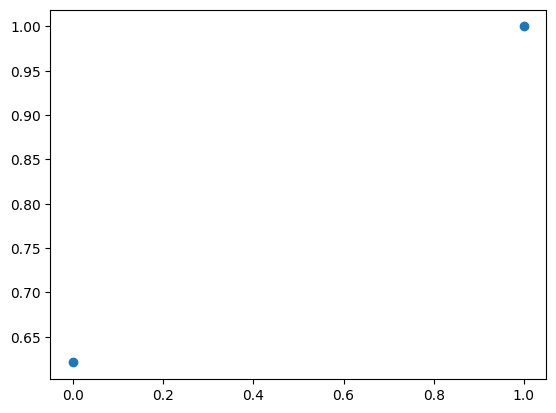

In [129]:
plt.scatter([0,1], 
            time_series_ph[['Cosine_similarity(w_t_reference-last,w_t0)',
                           'Cosine_similarity(w_t_reference-last,w_t1)'
                           ]].iloc[0])
plt.show()

Rearrange the dataframe for visualization:

In [130]:
time_series_ph.columns

Index(['Word', 'Frequency_t_reference-last', 'Frequency_t0',
       'Cosine_similarity(w_t_reference-last,w_t0)', 'interval-0',
       'neighbours_t0', 'Frequency_t1',
       'Cosine_similarity(w_t_reference-last,w_t1)', 'interval-1',
       'neighbours_t1'],
      dtype='object')

In [131]:
time_series_ph

,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)",interval-0,neighbours_t0,Frequency_t1,"Cosine_similarity(w_t_reference-last,w_t1)",interval-1,neighbours_t1
0,et,128676,117636,0.621083,0,"[(atque, 0.6401287317276001), (quis#2, 0.57998...",128676,1,1,"[(is, 0.5970924496650696), (cum, 0.48844689130..."
1,sum,84730,94747,0.713389,0,"[(hic, 0.5563845038414001), (quis#2, 0.5560562...",84730,1,1,"[(hic, 0.5742835998535156), (habeo, 0.54451811..."
2,in,64137,73628,0.700500,0,"[(ex, 0.505215585231781), (et, 0.4878416359424...",64137,1,1,"[(ex, 0.5208931565284729), (cum, 0.51963305473..."
3,quis#2,56687,67421,0.700725,0,"[(quod, 0.6888918280601501), (hic, 0.617911219...",56687,1,1,"[(qui, 0.6749013662338257), (hic, 0.6184121370..."
4,is,47487,44812,0.659561,0,"[(hic, 0.5448647737503052), (sum, 0.5392197966...",47487,1,1,"[(et, 0.5970924496650696), (non, 0.58682405948..."
...,...,...,...,...,...,...,...,...,...,...
4052,consolatio,75,83,0.499165,0,"[(dispositio, 0.5278289914131165), (supervacuu...",75,1,1,"[(consolo, 0.6027289032936096), (tristitia, 0...."
4053,VII,75,83,0.592301,0,"[(V, 0.7383232116699219), (VIII, 0.70414137840...",75,1,1,"[(X, 0.8359005451202393), (II, 0.8286216855049..."
4054,deceptus,75,83,0.504375,0,"[(meretrix, 0.4613407552242279), (uana, 0.4442...",75,1,1,"[(callidus, 0.5539202690124512), (dissimulo, 0..."
4055,sibilus,75,83,0.593469,0,"[(stridor, 0.6936538219451904), (raucus, 0.639...",75,1,1,"[(tremulus, 0.5762055516242981), (serpo, 0.556..."


In [132]:
time_series_ph1 = pd.DataFrame()
for index, row in time_series_ph.iterrows():
    #print(row['interval-0'], row['Cosine_similarity(w_t_reference-last,w_t0)'])
    
    #temp = pd.DataFrame(
    #    {
    #        'Time_interval': row['interval-0'],
    #        'Cosine_sim': row['Cosine_similarity(w_t_reference-last,w_t0)'],
    #        'Word': row['Word']
    #    }
    #)
    #print([row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']])
    #print(pd.DataFrame(
    #    [row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']]))
    time_series_ph1 = pd.concat([time_series_ph1, pd.DataFrame(
        [row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']]).transpose()])
    time_series_ph1 = pd.concat([time_series_ph1, pd.DataFrame(
        [row['interval-1'],row['Cosine_similarity(w_t_reference-last,w_t1)'],row['Word']]).transpose()])
    #print(time_series_df1)

time_series_ph1.columns = ['Time_interval', 'Cosine_sim', 'Word']
time_series_ph1

,Time_interval,Cosine_sim,Word
0,0,0.621083,et
0,1,1,et
0,0,0.713389,sum
0,1,1,sum
0,0,0.7005,in
...,...,...,...
0,1,1,deceptus
0,0,0.593469,sibilus
0,1,1,sibilus
0,0,0.677345,pipo


Print to output file:

In [98]:
time_series_ph1.to_csv(os.path.join(dir_out, 'semantic_change1_'+str(size_interval)+'_allwords.csv'), index=None) 

List of words which changed under the push of Christianity:

In [89]:
christian_terms = ["scriptura", "virtus", "gratia", "sanctus", "deus", "deductor", "oratio", "communico", "lex", "altarium", "tabernaculum", "beatus", "benedico", "commoror", "suscipio", "memoria", "deputo", "recessus", "frater", "soror", "canticum", "facies", "poto"]

In [90]:
time_series_ph_chr = time_series_ph[time_series_ph['Word'].isin(christian_terms)]
time_series_ph_chr.to_csv(os.path.join(dir_out, 'semantic_change_'+str(size_interval)+'_christianwords.csv'), index=None) 
time_series_ph_chr

,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)",interval-0,neighbours_t0,Frequency_t1,"Cosine_similarity(w_t_reference-last,w_t1)",interval-1,neighbours_t1
32,deus,10060,12013,0.618055,0,"[(numen, 0.6655447483062744), (dea, 0.66228300...",10060,1,1,"[(dominus, 0.6209409236907959), (omnipotens, 0..."
111,lex,3367,4174,0.756335,0,"[(ius, 0.5928292870521545), (jus, 0.5857967138...",3367,1,1,"[(constitutio, 0.6680530309677124), (observati..."
172,frater,2203,2757,0.658401,0,"[(soror, 0.6878962516784668), (nepos, 0.675656...",2203,1,1,"[(patruus, 0.7018540501594543), (soror, 0.6447..."
198,sanctus,1917,2343,0.475866,0,"[(sancio, 0.6898450255393982), (religiosus, 0....",1917,1,1,"[(beatus, 0.6218249797821045), (beo, 0.5346924..."
207,virtus,1812,2249,0.716555,0,"[(sapientia, 0.7030335068702698), (prudentia, ...",1812,1,1,"[(fortitudo, 0.653775155544281), (gloria, 0.61..."
250,gratia,1539,1867,0.559681,0,"[(dignitas, 0.5600572228431702), (beneficium, ...",1539,1,1,"[(consolatio, 0.46341991424560547), (paenitent..."
255,oratio,1519,1852,0.545102,0,"[(disputatio, 0.7186176776885986), (sermo, 0.6...",1519,1,1,"[(lectio, 0.5930050611495972), (vigilia, 0.449..."
385,facies,1052,1325,0.477942,0,"[(color, 0.6378708481788635), (forma, 0.597008...",1052,1,1,"[(oculus, 0.6613511443138123), (os#2, 0.555164..."
464,suscipio,865,1112,0.542252,0,"[(administro, 0.5455198884010315), (conservo, ...",865,1,1,"[(accipio, 0.6038733720779419), (recipio, 0.59..."
527,memoria,774,963,0.744845,0,"[(posteritas, 0.6096746325492859), (antiquitas...",774,1,1,"[(antiquitas, 0.5913469195365906), (commentari..."


In [135]:
time_series_ph1_chr = time_series_ph1[time_series_ph1['Word'].isin(christian_terms)]
time_series_ph1_chr.to_csv(os.path.join(dir_out, 'semantic_change1_'+str(size_interval)+'_christianwords.csv'), index=None) 
time_series_ph1_chr

,Time_interval,Cosine_sim,Word
0,0,0.662271,deus
0,1,1,deus
0,0,0.64048,lex
0,1,1,lex
0,0,0.554297,frater
0,1,1,frater
0,0,0.432042,sanctus
0,1,1,sanctus
0,0,0.53758,virtus
0,1,1,virtus


In [136]:
time_series_ph1_chr.dtypes

Time_interval    object
Cosine_sim       object
Word             object
dtype: object

In [137]:
time_series_ph1_chr["Time_interval"] = pd.to_numeric(time_series_ph1_chr["Time_interval"], downcast='integer')

/var/folders/3d/s1l2k39n20xf5qg589sk0yhw0000gp/T/ipykernel_14755/1829912458.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [138]:
time_series_ph1_chr["Cosine_sim"] = pd.to_numeric(time_series_ph1_chr["Cosine_sim"], downcast='float')

/var/folders/3d/s1l2k39n20xf5qg589sk0yhw0000gp/T/ipykernel_14755/3220937122.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



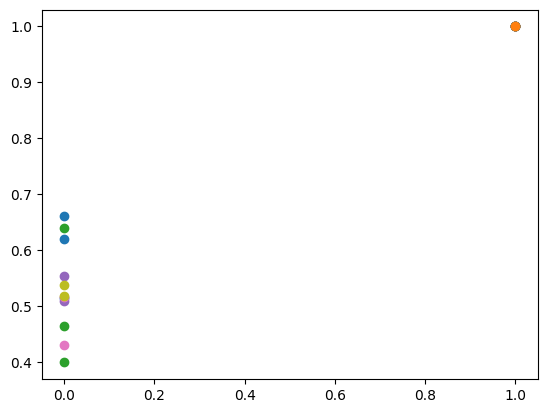

In [139]:
for i in range(len(christian_terms)):
    plt.scatter(time_series_ph1_chr[['Time_interval']].iloc[i], 
            time_series_ph1_chr[['Cosine_sim']].iloc[i])
plt.show()

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-p

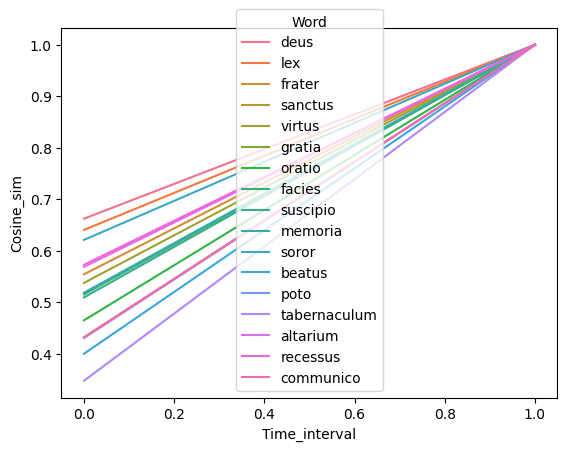

In [140]:
import seaborn as sns
#sns.lmplot('Time_interval', 'Cosine_sim', data=time_series_ph1_chr, hue='Word', fit_reg=False)
sns.lineplot(x='Time_interval', y='Cosine_sim', data=time_series_ph1_chr, hue='Word', legend="full")
plt.show()

QUESTION: Once again, help with graph interepretation!!

## Train embeddings for Christian and non-Christian subcorpora (post-150 AD)

### Christian

#### Make corpus

Create a list of lists, containing the (lemmatized) tokens of each sentence in the whole corpus (excluding punctuation):

In [33]:
corpus_christi = list()
files_corpus_christi = metadata_ph_christian
for index, df_line in files_corpus_christi.iterrows():
    #print("line:",df_line['id'], df_line['time_interval'])
    sign = "+"
    #print(df_line['date'])
    if df_line['date'] < 0:
        sign = "-"
    #print("date:", convert_dates(sign, abs(df_line['date'])))
    file_name = df_line['file'] #'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
    #print("3:",file_name)
    file = open(os.path.join(dir_in, "preprocessed_"+lemmas_or_tokens+"_2024", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            #sentences_this_file.append(line.split(" "))
            #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
            corpus_christi.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_christi.append(sentences_this_file)

In [142]:
corpus_christi

[['cogito',
  'ego',
  'et',
  'cum',
  'animus',
  'meus',
  'Octavius',
  'bonus',
  'et',
  'fidelis',
  'contubernalis',
  'memoria',
  'recenseo',
  'tantus',
  'dulcedo',
  'et',
  'adfectio',
  'homo',
  'inhaeresco',
  'ut',
  'ipse',
  'quodammodo',
  'ego',
  'video',
  'in',
  'praeteritus',
  'redeo',
  'non',
  'is',
  'quis#2',
  'iam',
  'transigo',
  'et',
  'decurro',
  'sum',
  'recordatio',
  'revoco',
  'ita',
  'is',
  'contemplatio',
  'quantum',
  'subtraho',
  'sum',
  'oculus',
  'tantus',
  'pectus',
  'meus',
  'atque',
  'paene',
  'intimus',
  'sensus',
  'inplicata',
  'sum'],
 ['nec',
  'inmeritum',
  'discedo',
  'vir',
  'eximius',
  'et',
  'sanctus',
  'inmensum',
  'suus',
  'desiderium',
  'nos',
  'relinquo',
  'utpote',
  'cum',
  'et',
  'ipse',
  'tanto',
  'noster',
  'semper',
  'amor',
  'flagraverit',
  'ut',
  'et',
  'in',
  'ludicrum',
  'et',
  'seria',
  'par',
  'ego',
  'voluntas',
  'concino',
  'idem',
  'volo#1',
  'vel',
  'nolo',

In [34]:
len(corpus_christi)

99464

In [35]:
num_words_corpus_christi = sum(len(i) for i in corpus_christi)
num_words_corpus_christi

1750874

#### Train with FastText and play with parameters

In [107]:
start = time.time()
model_christi = FastText(vector_size=100, alpha=0.025, window=5, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0,
                  sentences=corpus_christi)
end = time.time()
print("It has taken", round(end - start), "seconds")

It has taken 5 seconds


Let's see what words are similar to "deus":

In [146]:
model_christi.wv.similar_by_word('deus', 10)

[('omnipotens', 0.6860058307647705),
 ('maiestas', 0.6623215079307556),
 ('creator', 0.6365839838981628),
 ('gloria', 0.6333969235420227),
 ('dominus', 0.6284407377243042),
 ('misericordia', 0.6273282766342163),
 ('genitor', 0.6271489262580872),
 ('pater', 0.6249731183052063),
 ('caritas', 0.6228201985359192),
 ('justitia', 0.61931312084198)]

In [110]:
model_christi.wv.similar_by_word('oratio', 10)

[('hymnus', 0.7042149901390076),
 ('consuetudo', 0.6423172950744629),
 ('lego#2', 0.6338802576065063),
 ('dominicus', 0.6218238472938538),
 ('evangelium', 0.6184514164924622),
 ('lectio', 0.6146638989448547),
 ('ecclesia', 0.6126869320869446),
 ('epistula', 0.5903208255767822),
 ('praedicatio', 0.5876262187957764),
 ('vaco', 0.586397111415863)]

In [102]:
model_christi.wv.similar_by_word('communico', 10)

[('deputo', 0.9329729080200195),
 ('profiteor', 0.9321633577346802),
 ('recognosco', 0.9302098751068115),
 ('consentio', 0.9291950464248657),
 ('competo', 0.9258091449737549),
 ('adscribo', 0.9235137104988098),
 ('deprehendo', 0.9231653213500977),
 ('comparo', 0.9203287959098816),
 ('suppeto', 0.9183707237243652),
 ('conpello', 0.913794219493866)]

In [147]:
#model_christi.wv.similar_by_word('eremus', 10)

### Non-christian

#### Make corpus

Create a list of lists, containing the (lemmatized) tokens of each sentence in the whole corpus (excluding punctuation):

In [39]:
corpus_non_christi = list()
files_corpus_non_christi = metadata_ph_nonchristian
for index, df_line in files_corpus_non_christi.iterrows():
    #print("line:",df_line['id'], df_line['time_interval'])
    sign = "+"
    #print(df_line['date'])
    if df_line['date'] < 0:
        sign = "-"
    #print("date:", convert_dates(sign, abs(df_line['date'])))
    file_name = df_line['file'] #'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
    #print("3:",file_name)
    file = open(os.path.join(dir_in, "preprocessed_"+lemmas_or_tokens+"_2024", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            #sentences_this_file.append(line.split(" "))
            #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
            corpus_non_christi.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_non_christi.append(sentences_this_file)

In [149]:
corpus_non_christi

[['jucundus',
  'alius',
  'reperiri',
  'queunt',
  'ad',
  'hic',
  'ut',
  'liberi',
  'quoque',
  'meus',
  'pario',
  'istiusmodi',
  'remissio',
  'sum',
  'quando',
  'animus',
  'is',
  'interstitione',
  'aliquis',
  'negotium',
  'do',
  'laxari',
  'indulgerique',
  'possum'],
 ['utor',
  'autem',
  'sum',
  'ordo',
  'res',
  'fortuito',
  'quis#2',
  'antea',
  'in',
  'excerpo',
  'facio'],
 ['nam',
  'proinde',
  'ut',
  'liber#4',
  'quisque',
  'in',
  'manus',
  'capio',
  'sive',
  'Graecus',
  'sive',
  'Latinum',
  'vel',
  'quis#2',
  'memoro',
  'dignus',
  'audio',
  'ita',
  'quis#2',
  'libitum',
  'sum',
  'quis#2',
  'genus',
  'cumque',
  'sum',
  'indistinctus',
  'atque',
  'promisce',
  'annoto',
  'eaque',
  'ego',
  'ad',
  'subsidium',
  'memoria',
  'quasi',
  'quidam',
  'litterae',
  'penus',
  'recondo',
  'ut',
  'quando',
  'usus',
  'venio',
  'aut',
  'reus',
  'aut',
  'verbum',
  'quis#2',
  'ego',
  'repens',
  'forte',
  'oblivio',
  'tene

In [150]:
len(corpus_non_christi)

118715

In [151]:
num_words_corpus_non_christi = sum(len(i) for i in corpus_non_christi)
num_words_corpus_non_christi

1380104

#### Train with FastText and play with parameters

In [108]:
start = time.time()
model_non_christi = FastText(vector_size=100, alpha=0.025, window=5, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0,
                  sentences=corpus_non_christi)
end = time.time()
print("It has taken", round(end - start), "seconds")

It has taken 4 seconds


Let's see what words are similar to "deus":

In [153]:
model_non_christi.wv.similar_by_word('deus', 10)

[('numen', 0.8484166264533997),
 ('o', 0.8446773290634155),
 ('amo', 0.842167854309082),
 ('pius', 0.841886579990387),
 ('carmen', 0.8269680738449097),
 ('amor', 0.8217057585716248),
 ('sanctus', 0.8197226524353027),
 ('tuuus', 0.8167752027511597),
 ('misereor', 0.8072478175163269),
 ('"', 0.7987004518508911)]

In [109]:
model_non_christi.wv.similar_by_word('oratio', 10)

[('litterae', 0.8151900768280029),
 ('Graecus', 0.8095364570617676),
 ('vocabulum', 0.8090505003929138),
 ('Varro', 0.8089194297790527),
 ('historia', 0.7976173162460327),
 ('regula', 0.7942489981651306),
 ('Latinum', 0.7853044867515564),
 ('Cicero', 0.7776352167129517),
 ('Cato', 0.7695586085319519),
 ('Tullius', 0.7483625411987305)]

In [104]:
model_non_christi.wv.similar_by_word('communico', 10)

[('caelicola', 0.9656903743743896),
 ('receptum', 0.9644109606742859),
 ('humilitas', 0.9632070660591125),
 ('aemulatio', 0.9630569219589233),
 ('aliquos', 0.9625380635261536),
 ('conperisset', 0.9623324275016785),
 ('ciuili', 0.9622730016708374),
 ('sacrificium', 0.9621590971946716),
 ('licenter', 0.9618822932243347),
 ('pulchritudo', 0.9615115523338318)]

In [122]:
# model_non_christi.wv.similar_by_word('eremus', 10)

### Embedding space alignment

In [155]:
smart_procrustes_align_gensim(model_christi, model_non_christi)

9444 9444
9444 9444
['et', 'sum', 'in', 'quis#2', 'is', 'non', 'hic', 'ab', 'ad', 'ut', 'cum', 'si', 'suus', 'de', 'quod', 'ille', 'omnis', 'dico#2', 'sed', 'deus', 'ipse', 'facio', 'ego', 'ex', 'per', 'se', 'vel', 'tu', 'autem', 'dominus', 'atque', 'possum', 'qui', 'tuus', 'nec', 'enim', 'habeo', 'filius', 'do', 'imperator', 'quam#4', 'alius', 'aut', 'meus', 'rex', 'video', 'res', 'homo', 'quia', 'nos', 'dies', 'etiam', 'noster', 'multus', 'pater', 'iam', 'terra', 'unus', 'tempus', 'pro', 'post', 'vos', 'venio', 'nomen', 'verus', 'ne#2', "'", 'conss', 'locus', 'tamen', 'bonus', 'quo', 'magnus', 'idem', 'sic', 'super', 'ita', 'nullus', 'pars', 'D', 'manus', 'primus', 'kalendae', 'Christus', 'vir', 'quoque', 'tantus', 'verbum', '"', 'corpus', 'iste', 'sanctus', 'lex', 'annus', 'solus', 'debeo', 'inter', 'causa', 'nunc', 'quidam', 'ergo', 'domus', 'tunc', 'populus', 'neque', 'vita', 'fio', 'dum', 'sicut', 'ago', 'namque', 'sub', 'sive', 'audio', 'credo', 'mors', 'sine', 'mitto', 'modus',

Now the two models have been aligned.

### Semantic change with cosine similarity

Define a function that calculates the cosine similarity between the embedding of a word in a model (=subcorpus) and the embedding of the same word in another model (=subcorpus):

In [156]:
def cosine_similarity_2(word, model0, model1):
    sc = 1-spatial.distance.cosine(model0.wv[word], model1.wv[word])
    return sc

In [157]:
cosine_similarity_2('deus', model_christi, model_non_christi)

0.5726780891418457

Now define a function that, given two models, calculates the semantic similarity for all words in the vocabulary between these two, and stores this in the dataframe cosine_similarity_ph_2:

In [158]:
def cosine_similarity_dataframe_2(model0, model1):
    cosine_similarity_ph_2 = pd.DataFrame(([w, 
            model0.wv.get_vecattr(w, "count"),
            model1.wv.get_vecattr(w, "count"),
            model0.wv.similar_by_word(w, 10),
            model1.wv.similar_by_word(w, 10),                            
            cosine_similarity_2(w, model0, model1)  
            ] for w in model0.wv.index_to_key), 
        columns = ('Word', "Frequency_t_model0", "Frequency_t_model1", "Neighbours_t_model0", "Neighbours_t_model1",
        'Cosine_similarity'))
    return cosine_similarity_ph_2

In [159]:
cosine_similarity_dataframe_2(model_christi,model_non_christi).to_csv(os.path.join(dir_out, 'semantic_similarity_post150_allwords.csv'), index=None)
cosine_similarity_dataframe_2(model_christi,model_non_christi)

KeyboardInterrupt: 

# BLOBBING #

In [160]:
time_series_ph[time_series_ph['Word']=='communico']

,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)",interval-0,neighbours_t0,Frequency_t1,"Cosine_similarity(w_t_reference-last,w_t1)",interval-1,neighbours_t1
3363,communico,97,108,0.431542,0,"[(praesertim, 0.48739904165267944), (relatio, ...",97,1,1,"[(communio, 0.4551532566547394), (conventus, 0..."


In [116]:
xx = [item for row in time2corpus[1] for item in row]
xx.count('oratio')

950

In [164]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('communio')

60

In [117]:
xx = [item for row in corpus_christi for item in row]
xx.count('oratio')

629

In [118]:
xx = [item for row in corpus_non_christi for item in row]
xx.count('oratio')

321

In [140]:
xx = [item for row in time2corpus[1] for item in row]
xx.count('communico')

106

In [141]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('communico')

74

In [142]:
xx = [item for row in corpus_christi for item in row]
xx.count('communico')

95

In [143]:
xx = [item for row in corpus_non_christi for item in row]
xx.count('communico')

11

In [ ]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('eremus')

In [ ]:
xx = [item for row in corpus_christi for item in row]
xx.count('eremus')

In [ ]:
xx = [item for row in corpus_christi for item in row]
xx.count('desertum')

In [ ]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('desertum')

In [ ]:
# with open('your_file.txt', 'w') as f:
#    for line in time2corpus[1]:
#        f.write(f"{line}\n")

In [ ]:
cosine_similarity_dataframe_2(model_christi,model_non_christi).iloc[19]

Visualise the distribution of the semantic similarity scores with a histogram:

In [ ]:
hist = cosine_similarity_dataframe_2(model_christi,model_non_christi).iloc[:,-1].hist()

In [ ]:
cosine_similarity_dataframe_2_chr = cosine_similarity_dataframe_2(model_christi,model_non_christi)[cosine_similarity_dataframe_2(model_christi,model_non_christi)['Word'].isin(christian_terms)]
cosine_similarity_dataframe_2_chr.to_csv(os.path.join(dir_out, 'semantic_similarity_post150_christianwords.csv'), index=None)
cosine_similarity_dataframe_2_chr

In [ ]:
christian_replacements = ['sabbatum', 'ecclesia', 'propheta', 'petra', 'eremus', 'patriarcha', 'martyrium', 'episcopus', 'gyro', 'gyrus']

In [ ]:
cosine_similarity_dataframe_2_chr_repl = cosine_similarity_dataframe_2(model_christi,model_non_christi)[cosine_similarity_dataframe_2(model_christi,model_non_christi)['Word'].isin(christian_replacements)]
cosine_similarity_dataframe_2_chr_repl.to_csv(os.path.join(dir_out, 'semantic_similarity_post150_christianreplacements.csv'), index=None)
cosine_similarity_dataframe_2_chr_repl

In [ ]:
model_christi.wv.similar_by_word('memoria', 10)

In [ ]:
model_non_christi.wv.similar_by_word('memoria', 10)

In [ ]:
model_christi.wv.similar_by_word('communico', 10)

In [ ]:
model_non_christi.wv.similar_by_word('communico', 10)

In [ ]:
model_christi.wv.similar_by_word('sanctus', 10)

In [ ]:
model_non_christi.wv.similar_by_word('sanctus', 10)

In [ ]:
model_christi.wv.similar_by_word('virtus', 10)